# Molecular Structure & Property Explorer


## Part I — Environment & Dataset

### 01. Project Overview

This project explores molecular structure, property prediction, and cheminformatics analysis using the ESOL dataset and RDKit-based workflows.

### 02. Environment Setup

* Python environment
* RDKit
* NumPy
* Pandas
* Matplotlib
* Jupyter Notebook


In [23]:
%%capture
%pip install pandas numpy matplotlib seaborn rdkit

In [24]:
# Core data science
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Cheminformatics
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors

print("Environment ready!")
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("RDKit:", Chem.rdBase.rdkitVersion)

Environment ready!
Pandas: 3.0.5
NumPy: 2.5.3
RDKit: 2026.03.6


### 03. Load ESOL Dataset

* Load CSV
* Inspect dataset
* Identify target/property columns


In [25]:
import pandas as pd

data = pd.read_csv("data\delaney-processed.csv")

data.head()

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\rasel\AppData\Local\Temp\ipykernel_8324\942561932.py:3: SyntaxWarning: invalid escape sequence '\d'
  data = pd.read_csv("data\delaney-processed.csv")


,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


| Column                          | What it represents                 | Category              |
| ------------------------------- | ---------------------------------- | --------------------- |
| `Compound ID`                   | Molecule name/identifier           | Identification        |
| `ESOL predicted log solubility` | Model-predicted logS               | Prediction            |
| `Minimum Degree`                | Minimum atom connectivity degree   | Graph descriptor      |
| `Molecular Weight`              | Molecular mass                     | Property              |
| `Number of H-Bond Donors`       | H-bond donating groups             | Property              |
| `Number of Rings`               | Ring count                         | Structural descriptor |
| `Number of Rotatable Bonds`     | Molecular flexibility              | Structural descriptor |
| `Polar Surface Area`            | Molecular polarity                 | Property              |
| `measured log solubility`       | Experimental/reference logS        | Target                |
| `smiles`                        | Molecular structure representation | Representation        |


### 04. Dataset Inspection


In [26]:
# Column names
data.columns

Index(['Compound ID', 'ESOL predicted log solubility in mols per litre',
       'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors',
       'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area',
       'measured log solubility in mols per litre', 'smiles'],
      dtype='str')

In [27]:
# Column names as Python list
data.columns.tolist()

['Compound ID',
 'ESOL predicted log solubility in mols per litre',
 'Minimum Degree',
 'Molecular Weight',
 'Number of H-Bond Donors',
 'Number of Rings',
 'Number of Rotatable Bonds',
 'Polar Surface Area',
 'measured log solubility in mols per litre',
 'smiles']

In [28]:
print(len(data.columns))

10


In [29]:
# Dataset information
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 10 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Compound ID                                      1128 non-null   str    
 1   ESOL predicted log solubility in mols per litre  1128 non-null   float64
 2   Minimum Degree                                   1128 non-null   int64  
 3   Molecular Weight                                 1128 non-null   float64
 4   Number of H-Bond Donors                          1128 non-null   int64  
 5   Number of Rings                                  1128 non-null   int64  
 6   Number of Rotatable Bonds                        1128 non-null   int64  
 7   Polar Surface Area                               1128 non-null   float64
 8   measured log solubility in mols per litre        1128 non-null   float64
 9   smiles                                   

In [30]:
# Data types
data.dtypes

Compound ID                                            str
ESOL predicted log solubility in mols per litre    float64
Minimum Degree                                       int64
Molecular Weight                                   float64
Number of H-Bond Donors                              int64
Number of Rings                                      int64
Number of Rotatable Bonds                            int64
Polar Surface Area                                 float64
measured log solubility in mols per litre          float64
smiles                                                 str
dtype: object

In [31]:
# Missing values
data.isnull().sum()

Compound ID                                        0
ESOL predicted log solubility in mols per litre    0
Minimum Degree                                     0
Molecular Weight                                   0
Number of H-Bond Donors                            0
Number of Rings                                    0
Number of Rotatable Bonds                          0
Polar Surface Area                                 0
measured log solubility in mols per litre          0
smiles                                             0
dtype: int64

In [32]:
# Dataset dimensions
data.shape

(1128, 10)

In [33]:
# Statistical summary
data.describe()

,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre
count,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000
mean,-2.988192,1.058511,203.937074,0.701241,1.390957,2.177305,34.872881,-3.050102
std,1.683220,0.238560,102.738077,1.089727,1.318286,2.640974,35.383593,2.096441
min,-9.702000,0.000000,16.043000,0.000000,0.000000,0.000000,0.000000,-11.600000
25%,-3.948250,1.000000,121.183000,0.000000,0.000000,0.000000,0.000000,-4.317500
50%,-2.870000,1.000000,182.179000,0.000000,1.000000,1.000000,26.300000,-2.860000
75%,-1.843750,1.000000,270.372000,1.000000,2.000000,3.000000,55.440000,-1.600000
max,1.091000,2.000000,780.949000,11.000000,8.000000,23.000000,268.680000,1.580000


In [34]:
# Duplicate rows
data.duplicated().sum()

np.int64(0)

In [35]:
# Duplicate molecules based on SMILES
data["smiles"].duplicated().sum()

np.int64(0)

## Part II — Molecular Representation

### 06. SMILES Fundamentals

> SMILES = Simplified Molecular Input Line Entry System
>
> This is the text representation of the molecular structure.
>
> From SMILES, you can generate:

* 2D structure
* molecular properties
* descriptors
* fingerprints
* molecular similarity
* molecular graph
* drug-likeness calculations


In [36]:
from rdkit import Chem, DataStructs
from rdkit.Chem import (
    Draw,
    Descriptors,
    Crippen,
    Lipinski,
    rdMolDescriptors,
    QED
)

from rdkit.Chem import AllChem
from rdkit.Chem import MACCSkeys

In [37]:
print("Total records:", len(data))
print("Valid molecules:", len(data))

Total records: 1128
Valid molecules: 1128


### 07. SMILES → RDKit Molecule


In [42]:
# SMILES → RDKit Mol
data["mol"] = data["smiles"].apply(
    Chem.MolFromSmiles
)

In [44]:
print(data["mol"].head(10))

0    <rdkit.Chem.rdchem.Mol object at 0x0000019E93A...
1    <rdkit.Chem.rdchem.Mol object at 0x0000019E93A...
2    <rdkit.Chem.rdchem.Mol object at 0x0000019E93A...
3    <rdkit.Chem.rdchem.Mol object at 0x0000019E93A...
4    <rdkit.Chem.rdchem.Mol object at 0x0000019E93A...
5    <rdkit.Chem.rdchem.Mol object at 0x0000019E93A...
6    <rdkit.Chem.rdchem.Mol object at 0x0000019E93A...
7    <rdkit.Chem.rdchem.Mol object at 0x0000019E93A...
8    <rdkit.Chem.rdchem.Mol object at 0x0000019E93A...
9    <rdkit.Chem.rdchem.Mol object at 0x0000019E93A...
Name: mol, dtype: object


### 09. 2D Molecular Structure


In [45]:
from rdkit import Chem
from rdkit.Chem import rdDepictor


# Generate 2D coordinates
def generate_2d(mol):
    if mol is None:
        return None

    mol = Chem.Mol(mol)  # make a copy
    rdDepictor.Compute2DCoords(mol)

    return mol

In [ ]:
# apply 2D coordinates
data["mol_2d"] = data["mol"].apply(generate_2d)

print("2D structures generated:", data["mol_2d"].notna().sum())

2D structures generated: 1128


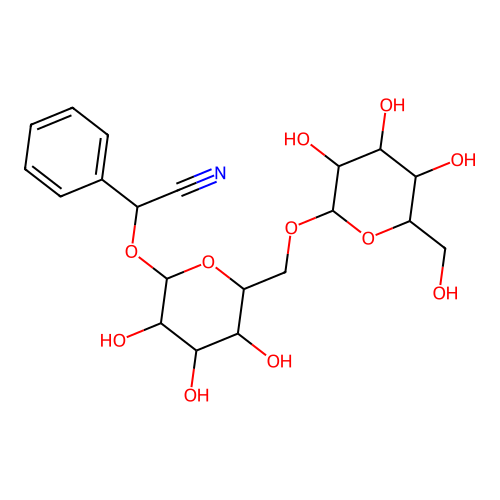

In [47]:
from rdkit.Chem import Draw

mol = data["mol_2d"].dropna().iloc[0]

Draw.MolToImage(
    mol,
    size=(500, 500)
)

In [49]:
# mols = data["mol_2d"].head(12).tolist()

# legends = data["Compound ID"].head(12).tolist()

# Draw.MolsToGridImage(
#     mols,
#     legends=legends,
#     molsPerRow=4,
#     subImgSize=(300, 300)
# )

In [52]:
# Molecular Properties
def calculate_molecular_properties(mol):
    return {
        "MolecularWeight": Descriptors.MolWt(mol),
        "ExactMolWeight": Descriptors.ExactMolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "RotatableBonds": Lipinski.NumRotatableBonds(mol),
        "HeavyAtomCount": Lipinski.HeavyAtomCount(mol),
        "RingCount": rdMolDescriptors.CalcNumRings(mol),
        "AromaticRingCount": rdMolDescriptors.CalcNumAromaticRings(mol),
        "FractionCSP3": rdMolDescriptors.CalcFractionCSP3(mol),
        "FormalCharge": Chem.GetFormalCharge(mol),
        "MolMR": Crippen.MolMR(mol),
    }


In [53]:
properties = data["mol"].apply(
    calculate_molecular_properties
)

properties_df = pd.DataFrame(
    properties.tolist(),
    index=data.index
)

data = pd.concat(
    [data, properties_df],
    axis=1
)

In [54]:
data[
    [
        "Compound ID",
        "MolecularWeight",
        "LogP",
        "TPSA",
        "HBD",
        "HBA",
        "RotatableBonds",
        "HeavyAtomCount",
        "RingCount",
        "AromaticRingCount",
        "FractionCSP3",
        "FormalCharge",
        "MolMR"
    ]
].head()

,Compound ID,MolecularWeight,LogP,TPSA,HBD,HBA,RotatableBonds,HeavyAtomCount,RingCount,AromaticRingCount,FractionCSP3,FormalCharge,MolMR
0,Amigdalin,457.432,-3.10802,202.32,7,12,7,32,3,1,0.650000,0,102.2816
1,Fenfuram,201.225,2.84032,42.24,1,2,2,15,2,2,0.083333,0,57.8402
2,citral,152.237,2.87800,17.07,0,1,4,11,0,0,0.500000,0,48.4860
3,Picene,278.354,6.29940,0.00,0,0,0,22,5,5,0.000000,0,96.4660
4,Thiophene,84.143,1.74810,0.00,0,1,0,5,1,1,0.000000,0,24.3190


In [55]:
# RDKit Descriptor Set

def calculate_all_descriptors(mol):
    return Descriptors.CalcMolDescriptors(
        mol,
        missingVal=np.nan
    )

In [56]:
descriptor_dicts = data["mol"].apply(
    calculate_all_descriptors
)

In [57]:
descriptor_df = pd.DataFrame(
    descriptor_dicts.tolist(),
    index=data.index
)

In [58]:
descriptor_df.shape

(1128, 217)

In [59]:
# Inspect descriptor names

descriptor_df.columns.tolist()

['MaxAbsEStateIndex',
 'MaxEStateIndex',
 'MinAbsEStateIndex',
 'MinEStateIndex',
 'qed',
 'SPS',
 'MolWt',
 'HeavyAtomMolWt',
 'ExactMolWt',
 'NumValenceElectrons',
 'NumRadicalElectrons',
 'MaxPartialCharge',
 'MinPartialCharge',
 'MaxAbsPartialCharge',
 'MinAbsPartialCharge',
 'FpDensityMorgan1',
 'FpDensityMorgan2',
 'FpDensityMorgan3',
 'BCUT2D_MWHI',
 'BCUT2D_MWLOW',
 'BCUT2D_CHGHI',
 'BCUT2D_CHGLO',
 'BCUT2D_LOGPHI',
 'BCUT2D_LOGPLOW',
 'BCUT2D_MRHI',
 'BCUT2D_MRLOW',
 'AvgIpc',
 'BalabanJ',
 'BertzCT',
 'Chi0',
 'Chi0n',
 'Chi0v',
 'Chi1',
 'Chi1n',
 'Chi1v',
 'Chi2n',
 'Chi2v',
 'Chi3n',
 'Chi3v',
 'Chi4n',
 'Chi4v',
 'HallKierAlpha',
 'Ipc',
 'Kappa1',
 'Kappa2',
 'Kappa3',
 'LabuteASA',
 'PEOE_VSA1',
 'PEOE_VSA10',
 'PEOE_VSA11',
 'PEOE_VSA12',
 'PEOE_VSA13',
 'PEOE_VSA14',
 'PEOE_VSA2',
 'PEOE_VSA3',
 'PEOE_VSA4',
 'PEOE_VSA5',
 'PEOE_VSA6',
 'PEOE_VSA7',
 'PEOE_VSA8',
 'PEOE_VSA9',
 'SMR_VSA1',
 'SMR_VSA10',
 'SMR_VSA2',
 'SMR_VSA3',
 'SMR_VSA4',
 'SMR_VSA5',
 'SMR_VSA6',


In [60]:
descriptor_df.head()

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,10.253329,10.253329,0.486602,-1.701605,0.217518,41.062500,457.432,430.216,457.158411,178,...,0,0,0,0,0,0,0,0,0,0
1,11.724911,11.724911,0.145880,-0.145880,0.811283,9.933333,201.225,190.137,201.078979,76,...,0,0,0,0,0,0,0,0,0,0
2,10.020498,10.020498,0.845090,0.845090,0.343706,11.000000,152.237,136.109,152.120115,62,...,0,0,0,0,0,0,0,0,0,0
3,2.270278,2.270278,1.301055,1.301055,0.291526,11.636364,278.354,264.242,278.109550,102,...,0,0,0,0,0,0,0,0,0,0
4,2.041667,2.041667,1.712963,1.712963,0.448927,8.000000,84.143,80.111,84.003371,26,...,0,0,0,0,0,0,0,1,0,0


## Part III — Molecular Descriptors

### 21. What Are Molecular Descriptors?

- EState
- Chi
- Kappa
- BalabanJ
- BertzCT
- MolMR
- Fraction Csp3


In [61]:
advanced_descriptor_names = [
    "BalabanJ",
    "BertzCT",
    "MolMR",
    "FractionCSP3",
    "Chi0n",
    "Chi1n",
    "Chi2n",
    "Chi3n",
    "Chi4n",
    "Kappa1",
    "Kappa2",
    "Kappa3"
]

In [62]:
available = [
    col
    for col in advanced_descriptor_names
    if col in descriptor_df.columns
]

descriptor_df[available].head()

,BalabanJ,BertzCT,MolMR,FractionCSP3,Chi0n,Chi1n,Chi2n,Chi3n,Chi4n,Kappa1,Kappa2,Kappa3
0,1.654937,759.662938,102.2816,0.650000,16.862520,9.998816,7.601218,5.431494,3.506930,24.903474,10.926356,5.251706
1,2.148162,459.484175,57.8402,0.083333,8.357948,4.676643,3.210611,2.135103,1.340444,9.522160,4.002882,2.070849
2,3.625760,171.311799,48.4860,0.500000,7.554513,3.908188,2.969252,1.443820,0.788002,10.150000,5.899351,7.042356
3,2.041379,1071.547817,96.4660,0.000000,12.082904,7.636751,5.829201,4.648219,3.586716,11.762233,4.315741,1.523286
4,3.125000,60.124818,24.3190,0.000000,2.717649,1.471405,0.793148,0.425381,0.226805,2.912766,1.221050,0.484065


### Extract atoms

In [63]:
def atom_features(mol):
    features = []

    for atom in mol.GetAtoms():
        features.append({
            "atom_index": atom.GetIdx(),
            "symbol": atom.GetSymbol(),
            "atomic_number": atom.GetAtomicNum(),
            "degree": atom.GetDegree(),
            "formal_charge": atom.GetFormalCharge(),
            "total_h": atom.GetTotalNumHs(),
            "hybridization": str(atom.GetHybridization()),
            "aromatic": atom.GetIsAromatic(),
            "in_ring": atom.IsInRing(),
        })

    return pd.DataFrame(features)

In [64]:
mol = data.iloc[0]["mol"]

atom_df = atom_features(mol)

atom_df

,atom_index,symbol,atomic_number,degree,formal_charge,total_h,hybridization,aromatic,in_ring
0,0,O,8,1,0,1,SP3,False,False
1,1,C,6,2,0,2,SP3,False,False
2,2,C,6,3,0,1,SP3,False,True
3,3,O,8,2,0,0,SP3,False,True
4,4,C,6,3,0,1,SP3,False,True
5,5,O,8,2,0,0,SP3,False,False
6,6,C,6,2,0,2,SP3,False,False
7,7,C,6,3,0,1,SP3,False,True
8,8,O,8,2,0,0,SP3,False,True
9,9,C,6,3,0,1,SP3,False,True


### Molecular Graph Edges

In [65]:
def bond_features(mol):
    bonds = []

    for bond in mol.GetBonds():
        bonds.append({
            "begin_atom": bond.GetBeginAtomIdx(),
            "end_atom": bond.GetEndAtomIdx(),
            "bond_type": str(bond.GetBondType()),
            "bond_order": bond.GetBondTypeAsDouble(),
            "aromatic": bond.GetIsAromatic(),
            "conjugated": bond.GetIsConjugated(),
            "in_ring": bond.IsInRing(),
        })

    return pd.DataFrame(bonds)

In [66]:
bond_df = bond_features(mol)

bond_df

,begin_atom,end_atom,bond_type,bond_order,aromatic,conjugated,in_ring
0,0,1,SINGLE,1.0,False,False,False
1,1,2,SINGLE,1.0,False,False,False
2,2,3,SINGLE,1.0,False,False,True
3,3,4,SINGLE,1.0,False,False,True
4,4,5,SINGLE,1.0,False,False,False
5,5,6,SINGLE,1.0,False,False,False
6,6,7,SINGLE,1.0,False,False,False
7,7,8,SINGLE,1.0,False,False,True
8,8,9,SINGLE,1.0,False,False,True
9,9,10,SINGLE,1.0,False,False,False


### Adjacency Matrix

In [67]:
def molecular_adjacency_matrix(mol):
    n_atoms = mol.GetNumAtoms()

    adjacency = np.zeros(
        (n_atoms, n_atoms),
        dtype=np.float32
    )

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        adjacency[i, j] = 1
        adjacency[j, i] = 1

    return adjacency

In [68]:
adj = molecular_adjacency_matrix(mol)

print(adj.shape)
print(adj)

(32, 32)
[[0. 1. 0. ... 0. 0. 0.]
 [1. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 1. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 1. 0.]]


### Weighted Adjacency Matrix

In [69]:
def weighted_adjacency_matrix(mol):
    n_atoms = mol.GetNumAtoms()

    adjacency = np.zeros(
        (n_atoms, n_atoms),
        dtype=np.float32
    )

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        order = bond.GetBondTypeAsDouble()

        adjacency[i, j] = order
        adjacency[j, i] = order

    return adjacency

### Morgan Fingerprints

In [70]:
from rdkit.Chem import rdFingerprintGenerator

morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

In [71]:
def morgan_fingerprint(mol):
    return morgan_generator.GetFingerprint(mol)

In [72]:
data["morgan_fp"] = data["mol"].apply(
    morgan_fingerprint
)

### Convert Morgan Fingerprints to NumPy

In [73]:
def fingerprint_to_numpy(fp):
    arr = np.zeros(
        (fp.GetNumBits(),),
        dtype=np.uint8
    )

    DataStructs.ConvertToNumpyArray(
        fp,
        arr
    )

    return arr

In [74]:
data["morgan_array"] = data["morgan_fp"].apply(
    fingerprint_to_numpy
)

In [75]:
X_morgan = np.vstack(
    data["morgan_array"].values
)

print(X_morgan.shape)

(1128, 2048)


### Morgan Fingerprint Information

In [76]:
from rdkit.Chem import rdFingerprintGenerator

morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

additional_output = rdFingerprintGenerator.AdditionalOutput()

additional_output.CollectBitInfoMap()

mol = data.iloc[0]["mol"]

fp = morgan_generator.GetFingerprint(
    mol,
    additionalOutput=additional_output
)

bit_info = additional_output.GetBitInfoMap()

print(bit_info)

{1: ((11, 0),), 80: ((1, 0), (6, 0)), 91: ((12, 2),), 170: ((4, 2),), 222: ((0, 1),), 321: ((11, 2),), 389: ((17, 2),), 413: ((9, 2),), 489: ((20, 2), (26, 2)), 610: ((7, 1), (2, 1)), 656: ((3, 0), (8, 0)), 674: ((12, 0),), 695: ((5, 0), (10, 0)), 790: ((13, 1),), 807: ((0, 0), (21, 0), (23, 0), (25, 0), (27, 0), (29, 0), (31, 0)), 823: ((5, 1),), 1019: ((2, 0), (4, 0), (7, 0), (9, 0), (20, 0), (22, 0), (24, 0), (26, 0), (28, 0), (30, 0)), 1028: ((14, 2),), 1037: ((22, 2), (28, 2)), 1088: ((16, 1), (17, 1), (18, 1)), 1136: ((6, 1),), 1148: ((6, 2),), 1199: ((16, 2), (18, 2)), 1234: ((2, 2),), 1257: ((21, 1), (23, 1), (25, 1), (27, 1), (29, 1), (31, 1)), 1323: ((9, 1), (4, 1)), 1365: ((14, 1),), 1369: ((12, 1),), 1380: ((14, 0),), 1384: ((13, 0),), 1487: ((20, 1), (22, 1), (26, 1), (28, 1), (24, 1), (30, 1)), 1505: ((10, 1),), 1516: ((1, 1),), 1581: ((15, 2), (19, 2)), 1750: ((15, 1), (19, 1)), 1764: ((1, 2),), 1806: ((10, 2),), 1844: ((24, 2), (30, 2)), 1873: ((15, 0), (16, 0), (17, 0)

### RDKit Fingerprint

In [77]:
rdkit_generator = rdFingerprintGenerator.GetRDKitFPGenerator(
    fpSize=2048
)

data["rdkit_fp"] = data["mol"].apply(
    rdkit_generator.GetFingerprint
)

### Atom Pair Fingerprint

In [78]:
atom_pair_generator = rdFingerprintGenerator.GetAtomPairGenerator(
    fpSize=2048
)

data["atom_pair_fp"] = data["mol"].apply(
    atom_pair_generator.GetFingerprint
)

### Topological Torsion Fingerprint

In [79]:
torsion_generator = rdFingerprintGenerator.GetTopologicalTorsionGenerator(
    fpSize=2048
)

data["torsion_fp"] = data["mol"].apply(
    torsion_generator.GetFingerprint
)

### MACCS Fingerprint

In [80]:
data["maccs_fp"] = data["mol"].apply(
    MACCSkeys.GenMACCSKeys
)

### Fingerprint Summary

In [81]:
print("Morgan:", len(data.iloc[0]["morgan_fp"]))
print("RDKit:", len(data.iloc[0]["rdkit_fp"]))
print("Atom Pair:", len(data.iloc[0]["atom_pair_fp"]))
print("Topological Torsion:", len(data.iloc[0]["torsion_fp"]))
print("MACCS:", len(data.iloc[0]["maccs_fp"]))

Morgan: 2048
RDKit: 2048
Atom Pair: 2048
Topological Torsion: 2048
MACCS: 167


## Part V — Molecular Similarity

### 40. Tanimoto Similarity

In [82]:
mol_a = data.iloc[0]["mol"]
mol_b = data.iloc[1]["mol"]

fp_a = morgan_generator.GetFingerprint(mol_a)
fp_b = morgan_generator.GetFingerprint(mol_b)

similarity = DataStructs.TanimotoSimilarity(
    fp_a,
    fp_b
)

print("Tanimoto similarity:", similarity)

Tanimoto similarity: 0.12307692307692308


### 42. Similarity Search


In [83]:
query_mol = data.iloc[0]["mol"]

query_fp = morgan_generator.GetFingerprint(
    query_mol
)

similarities = []

for idx, row in data.iterrows():

    fp = morgan_generator.GetFingerprint(
        row["mol"]
    )

    score = DataStructs.TanimotoSimilarity(
        query_fp,
        fp
    )

    similarities.append({
        "index": idx,
        "Compound ID": row["Compound ID"],
        "smiles": row["smiles"],
        "similarity": score
    })

In [84]:
similarity_df = pd.DataFrame(
    similarities
)

In [85]:
similarity_df = similarity_df.sort_values(
    "similarity",
    ascending=False
)

In [86]:
similarity_df.head(10)

,index,Compound ID,smiles,similarity
0,0,Amigdalin,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,1.000000
298,298,Raffinose,OCC1OC(CO)(OC2OC(COC3OC(CO)C(O)C(O)C3O)C(O)C(O...,0.438596
537,537,Salicin,OCC2OC(Oc1ccccc1CO)C(O)C(O)C2O,0.425926
1050,1050,Monotropitoside,COC(=O)c1ccccc1OC2OC(COC3OCC(O)C(O)C3O)C(O)C(O...,0.367647
441,441,Lactose,OCC1OC(OC2C(O)C(O)C(O)OC2CO)C(O)C(O)C1O,0.333333
1025,1025,Sucrose,OCC2OC(OC1(CO)OC(CO)C(O)C1O)C(O)C(O)C2O,0.333333
341,341,glucose,OCC1OC(O)C(O)C(O)C1O,0.297872
901,901,Fenpropathrin,CC1(C)C(C(=O)OC(C#N)c2cccc(Oc3ccccc3)c2)C1(C)C,0.264706
150,150,tubercidin,Nc1ncnc2n(ccc12)C3OC(CO)C(O)C3O,0.253731
458,458,Cypermethrin,CC1(C)C(C=C(Cl)Cl)C1C(=O)OC(C#N)c2cccc(Oc3cccc...,0.253333


### 43. Similarity Matrix


In [87]:
mols = data["mol"].tolist()

fps = [
    morgan_generator.GetFingerprint(mol)
    for mol in mols
]

In [88]:
n = len(fps)

similarity_matrix = np.zeros(
    (n, n),
    dtype=np.float32
)

In [89]:
for i in range(n):
    similarity_matrix[i, i] = 1.0

    for j in range(i + 1, n):

        score = DataStructs.TanimotoSimilarity(
            fps[i],
            fps[j]
        )

        similarity_matrix[i, j] = score
        similarity_matrix[j, i] = score

In [90]:
similarity_matrix.shape

(1128, 1128)

## Part VI — Drug-Likeness

### 45. Lipinski Rule of Five

In [91]:
def lipinski_analysis(mol):

    mw = Descriptors.MolWt(mol)
    logp = Crippen.MolLogP(mol)
    hbd = Lipinski.NumHDonors(mol)
    hba = Lipinski.NumHAcceptors(mol)

    violations = {
        "MW": mw > 500,
        "LogP": logp > 5,
        "HBD": hbd > 5,
        "HBA": hba > 10,
    }

    violation_count = sum(
        violations.values()
    )

    return {
        "MW": mw,
        "LogP": logp,
        "HBD": hbd,
        "HBA": hba,
        "Ro5_Violations": violation_count,
        "Ro5_Pass": violation_count <= 1,
    }

In [92]:
ro5_results = data["mol"].apply(
    lipinski_analysis
)

ro5_df = pd.DataFrame(
    ro5_results.tolist(),
    index=data.index
)

data = pd.concat(
    [data, ro5_df],
    axis=1
)

### 46. QED


In [93]:
data["QED"] = data["mol"].apply(
    QED.qed
)

In [94]:
data[
    [
        "Compound ID",
        "QED",
        "MW",
        "LogP",
        "HBD",
        "HBA",
        "Ro5_Violations"
    ]
].head()

,Compound ID,QED,MW,LogP,LogP,HBD,HBD,HBA,HBA,Ro5_Violations
0,Amigdalin,0.217518,457.432,-3.10802,-3.10802,7,7,12,12,2
1,Fenfuram,0.811283,201.225,2.84032,2.84032,1,1,2,2,0
2,citral,0.343706,152.237,2.87800,2.87800,0,0,1,1,0
3,Picene,0.291526,278.354,6.29940,6.29940,0,0,0,0,1
4,Thiophene,0.448927,84.143,1.74810,1.74810,0,0,1,1,0


### One Unified Molecular Analysis Function

In [95]:
def analyze_molecule(mol):

    if mol is None:
        return None

    properties = calculate_molecular_properties(mol)

    ro5 = lipinski_analysis(mol)

    descriptors = Descriptors.CalcMolDescriptors(
        mol,
        missingVal=np.nan
    )

    return {
        "properties": properties,
        "ro5": ro5,
        "descriptors": descriptors,
        "QED": QED.qed(mol),
        "num_atoms": mol.GetNumAtoms(),
        "num_bonds": mol.GetNumBonds(),
        "num_rings": rdMolDescriptors.CalcNumRings(mol),
        "formal_charge": Chem.GetFormalCharge(mol),
        "canonical_smiles": Chem.MolToSmiles(mol),
    }

In [96]:
result = analyze_molecule(
    data.iloc[0]["mol"]
)

result["properties"]

{'MolecularWeight': 457.4320000000001,
 'ExactMolWeight': 457.1584106839999,
 'LogP': -3.1080199999999985,
 'TPSA': 202.31999999999996,
 'HBD': 7,
 'HBA': 12,
 'RotatableBonds': 7,
 'HeavyAtomCount': 32,
 'RingCount': 3,
 'AromaticRingCount': 1,
 'FractionCSP3': 0.65,
 'FormalCharge': 0,
 'MolMR': 102.28160000000003}

### Complete Molecular Profile

In [97]:
def molecular_profile(mol):

    if mol is None:
        raise ValueError("Invalid molecule")

    profile = {
        "Canonical SMILES": Chem.MolToSmiles(mol),

        # Structure
        "Atoms": mol.GetNumAtoms(),
        "Bonds": mol.GetNumBonds(),
        "Rings": rdMolDescriptors.CalcNumRings(mol),
        "Formal Charge": Chem.GetFormalCharge(mol),

        # Properties
        "Molecular Weight": Descriptors.MolWt(mol),
        "Exact Molecular Weight": Descriptors.ExactMolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "Rotatable Bonds": Lipinski.NumRotatableBonds(mol),
        "Heavy Atoms": Lipinski.HeavyAtomCount(mol),
        "Fraction Csp3": rdMolDescriptors.CalcFractionCSP3(mol),
        "MolMR": Crippen.MolMR(mol),

        # Drug-likeness
        "QED": QED.qed(mol),
    }

    return profile

In [98]:
profile = molecular_profile(
    data.iloc[0]["mol"]
)

pd.Series(profile)

Canonical SMILES          N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...
Atoms                                                                    32
Bonds                                                                    34
Rings                                                                     3
Formal Charge                                                             0
Molecular Weight                                                    457.432
Exact Molecular Weight                                           457.158411
LogP                                                               -3.10802
TPSA                                                                 202.32
HBD                                                                       7
HBA                                                                      12
Rotatable Bonds                                                           7
Heavy Atoms                                                              32
Fraction Csp

## Part VII — Dataset Analysis

### 49. Molecular Summary DataFrame

* Number of molecules
* Missing values
* Duplicate molecules
* Unique SMILES
* Property ranges

In [99]:
print("Number of Molecules:", data["smiles"].nunique())

Number of Molecules: 1128


In [100]:
# Number of rows / records
print("Number of Rows:", len(data))

Number of Rows: 1128


In [101]:
# Number of unique molecules based on SMILES
print("Unique SMILES:", data["smiles"].nunique())

Unique SMILES: 1128


In [102]:
# Duplicate SMILES
print("Duplicate SMILES:", data["smiles"].duplicated().sum())

Duplicate SMILES: 0


In [103]:
# Missing values
print("\nMissing Values:")
print("*" * 55)
print(data.isnull().sum())


Missing Values:
*******************************************************
Compound ID                                        0
ESOL predicted log solubility in mols per litre    0
Minimum Degree                                     0
Molecular Weight                                   0
Number of H-Bond Donors                            0
Number of Rings                                    0
Number of Rotatable Bonds                          0
Polar Surface Area                                 0
measured log solubility in mols per litre          0
smiles                                             0
mol                                                0
mol_2d                                             0
MolecularWeight                                    0
ExactMolWeight                                     0
LogP                                               0
TPSA                                               0
HBD                                                0
HBA                       

In [104]:
# Property ranges
print("\nProperty Ranges:")

print("1. Molecular Weight:",
      data["Molecular Weight"].min(),
      "to",
      data["Molecular Weight"].max())

print("2. H-Bond Donors:",
      data["Number of H-Bond Donors"].min(),
      "to",
      data["Number of H-Bond Donors"].max())

print("3. Rings:",
      data["Number of Rings"].min(),
      "to",
      data["Number of Rings"].max())

print("4. Rotatable Bonds:",
      data["Number of Rotatable Bonds"].min(),
      "to",
      data["Number of Rotatable Bonds"].max())

print("5. Polar Surface Area:",
      data["Polar Surface Area"].min(),
      "to",
      data["Polar Surface Area"].max())

print("6. Measured logS:",
      data["measured log solubility in mols per litre"].min(),
      "to",
      data["measured log solubility in mols per litre"].max())

print("7. ESOL Predicted logS:",
      data["ESOL predicted log solubility in mols per litre"].min(),
      "to",
      data["ESOL predicted log solubility in mols per litre"].max())


print("8. Minimum Degree:",
      data["Minimum Degree"].min(),
      "to",
      data["Minimum Degree"].max())




Property Ranges:
1. Molecular Weight: 16.043 to 780.9490000000001
2. H-Bond Donors: 0 to 11
3. Rings: 0 to 8
4. Rotatable Bonds: 0 to 23
5. Polar Surface Area: 0.0 to 268.67999999999995
6. Measured logS: -11.6 to 1.58
7. ESOL Predicted logS: -9.702 to 1.091
8. Minimum Degree: 0 to 2


### 05. Data Cleaning & Validation

* Missing SMILES
* Invalid SMILES
* Duplicate molecules
* Invalid molecular structures

In [105]:
# missing smiles
print("\nMissing SMILES:", data["smiles"].isnull().sum())


Missing SMILES: 0


In [106]:
(data["smiles"].str.strip() == "").sum()

np.int64(0)

In [107]:
# Convert Mol → SMILES

In [108]:
# Convert SMILES → RDKit Mol
from rdkit import Chem

data["mol"] = data["smiles"].apply(Chem.MolFromSmiles)

In [109]:
print(data["mol"].head())

0    <rdkit.Chem.rdchem.Mol object at 0x0000019E9A6...
1    <rdkit.Chem.rdchem.Mol object at 0x0000019E9A6...
2    <rdkit.Chem.rdchem.Mol object at 0x0000019E9A6...
3    <rdkit.Chem.rdchem.Mol object at 0x0000019E9A6...
4    <rdkit.Chem.rdchem.Mol object at 0x0000019E9A6...
Name: mol, dtype: object


In [110]:
data[["Compound ID", "smiles", "mol"]].head()

,Compound ID,smiles,mol
0,Amigdalin,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,<rdkit.Chem.rdchem.Mol object at 0x0000019E9A6...
1,Fenfuram,Cc1occc1C(=O)Nc2ccccc2,<rdkit.Chem.rdchem.Mol object at 0x0000019E9A6...
2,citral,CC(C)=CCCC(C)=CC(=O),<rdkit.Chem.rdchem.Mol object at 0x0000019E9A6...
3,Picene,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,<rdkit.Chem.rdchem.Mol object at 0x0000019E9A6...
4,Thiophene,c1ccsc1,<rdkit.Chem.rdchem.Mol object at 0x0000019E9A6...


In [111]:
# Invalid SMILES
invalid_mols = data["mol"].isnull().sum()

print("Invalid SMILES:", invalid_mols)

Invalid SMILES: 0


In [112]:
# duplicate molecules based on RDKit Mol
duplicate_mols = data["mol"].duplicated().sum()
print("Duplicate Molecules:", duplicate_mols)

Duplicate Molecules: 0


In [113]:
data[data["smiles"].duplicated(keep=False)].sort_values("smiles")

,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles,...,atom_pair_fp,torsion_fp,maccs_fp,MW,LogP,HBD,HBA,Ro5_Violations,Ro5_Pass,QED


In [114]:
# canonical SMILES
data["canonical_smiles"] = data["mol"].apply(
    Chem.MolToSmiles
)

In [115]:
print(
    "Duplicate molecular structures:",
    data["canonical_smiles"].duplicated().sum()
)

Duplicate molecular structures: 11


In [116]:
# Remove Duplicate Molecular Structures
data = data.drop_duplicates(subset="canonical_smiles").copy()

In [117]:
data.head()

,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles,...,torsion_fp,maccs_fp,MW,LogP,HBD,HBA,Ro5_Violations,Ro5_Pass,QED,canonical_smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",457.432,-3.10802,7,12,2,False,0.217518,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2,...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",201.225,2.84032,1,2,0,True,0.811283,Cc1occc1C(=O)Nc1ccccc1
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O),...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",152.237,2.87800,0,1,0,True,0.343706,CC(C)=CCCC(C)=CC=O
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",278.354,6.29940,0,0,1,True,0.291526,c1ccc2c(c1)ccc1c2ccc2c3ccccc3ccc21
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1,...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",84.143,1.74810,0,1,0,True,0.448927,c1ccsc1


In [118]:
# print("Duplicate molecular structures after removal:", data)

## Part II — Molecular Representation

### 06. SMILES Fundamentals

> SMILES = Simplified Molecular Input Line Entry System
>
> This is the text representation of the molecular structure.
>
> From SMILES, you can generate:

* 2D structure
* molecular properties
* descriptors
* fingerprints
* molecular similarity
* molecular graph
* drug-likeness calculations


In [119]:
# Convert SMILES → Mol
data["mol"] = data["smiles"].apply(Chem.MolFromSmiles)

In [120]:
print(data["mol"].head())

0    <rdkit.Chem.rdchem.Mol object at 0x0000019E9A2...
1    <rdkit.Chem.rdchem.Mol object at 0x0000019E9A3...
2    <rdkit.Chem.rdchem.Mol object at 0x0000019E9A3...
3    <rdkit.Chem.rdchem.Mol object at 0x0000019E9A3...
4    <rdkit.Chem.rdchem.Mol object at 0x0000019E9A6...
Name: mol, dtype: object


In [121]:
# Convert Mol → SMILES
data["smiles"] = data["mol"].apply(Chem.MolToSmiles)

In [122]:
print(data["smiles"].head())

0    N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...
1                               Cc1occc1C(=O)Nc1ccccc1
2                                   CC(C)=CCCC(C)=CC=O
3                   c1ccc2c(c1)ccc1c2ccc2c3ccccc3ccc21
4                                              c1ccsc1
Name: smiles, dtype: str


In [123]:
# Check whether molecule is valid
data["is_valid"] = data["mol"].notnull()

In [124]:
# Validation summary
print("Total molecules:", len(data))
print("Valid molecules:", data["is_valid"].sum())
print("Invalid molecules:", (~data["is_valid"]).sum())

Total molecules: 1117
Valid molecules: 1117
Invalid molecules: 0


In [125]:
data['smiles'].head(10)

0    N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...
1                               Cc1occc1C(=O)Nc1ccccc1
2                                   CC(C)=CCCC(C)=CC=O
3                   c1ccc2c(c1)ccc1c2ccc2c3ccccc3ccc21
4                                              c1ccsc1
5                                        c1ccc2scnc2c1
6                  Clc1cc(Cl)c(-c2c(Cl)cccc2Cl)c(Cl)c1
7                       CC12CCC3c4ccc(O)cc4CCC3C1CCC2O
8       ClC1=C(Cl)C2(Cl)C3C4CC(C5OC45)C3C1(Cl)C2(Cl)Cl
9    C=C(C)C1Cc2c(ccc3c2OC2COc4cc(OC)c(OC)cc4C2C3=O)O1
Name: smiles, dtype: str

In [126]:
for name, smiles in zip(data['Compound ID'].head(10), data['smiles'].head(10)):
    print(f"{name:15} → {smiles}")

Amigdalin       → N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c1ccccc1
Fenfuram        → Cc1occc1C(=O)Nc1ccccc1
citral          → CC(C)=CCCC(C)=CC=O
Picene          → c1ccc2c(c1)ccc1c2ccc2c3ccccc3ccc21
Thiophene       → c1ccsc1
benzothiazole   → c1ccc2scnc2c1
2,2,4,6,6'-PCB  → Clc1cc(Cl)c(-c2c(Cl)cccc2Cl)c(Cl)c1
Estradiol       → CC12CCC3c4ccc(O)cc4CCC3C1CCC2O
Dieldrin        → ClC1=C(Cl)C2(Cl)C3C4CC(C5OC45)C3C1(Cl)C2(Cl)Cl
Rotenone        → C=C(C)C1Cc2c(ccc3c2OC2COc4cc(OC)c(OC)cc4C2C3=O)O1


In [127]:
# Molecular Representation Table

# total atoms
data["num_atoms"] = data["mol"].apply(lambda mol: mol.GetNumAtoms())

# total bonds
data["num_bonds"] = data["mol"].apply(lambda mol: mol.GetNumBonds())

# display the molecular representation table
data[["Compound ID", "smiles", "num_atoms", "num_bonds"]].head(10)

,Compound ID,smiles,num_atoms,num_bonds
0,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,32,34
1,Fenfuram,Cc1occc1C(=O)Nc1ccccc1,15,16
2,citral,CC(C)=CCCC(C)=CC=O,11,10
3,Picene,c1ccc2c(c1)ccc1c2ccc2c3ccccc3ccc21,22,26
4,Thiophene,c1ccsc1,5,5
5,benzothiazole,c1ccc2scnc2c1,9,10
6,"2,2,4,6,6'-PCB",Clc1cc(Cl)c(-c2c(Cl)cccc2Cl)c(Cl)c1,17,18
7,Estradiol,CC12CCC3c4ccc(O)cc4CCC3C1CCC2O,20,23
8,Dieldrin,ClC1=C(Cl)C2(Cl)C3C4CC(C5OC45)C3C1(Cl)C2(Cl)Cl,19,23
9,Rotenone,C=C(C)C1Cc2c(ccc3c2OC2COc4cc(OC)c(OC)cc4C2C3=O)O1,29,33


### 08. Canonical SMILES

* Atoms
* Bonds
* Branches
* Ring notation
* Charges
* Stereochemistry
* Aromatic atoms


In [128]:
from rdkit import Chem

# Number of atoms
data["atoms_number"] = data["mol"].apply(
    lambda mol: mol.GetNumAtoms()
)

# Number of bonds
data["bonds_number"] = data["mol"].apply(
    lambda mol: mol.GetNumBonds()
)

# Number of rings
data["rings_number"] = data["mol"].apply(
    lambda mol: mol.GetRingInfo().NumRings()
)

# Formal charge
data["formal_charge"] = data["mol"].apply(
    Chem.GetFormalCharge
)

# Stereochemistry / chiral centers
data["chiral_centers"] = data["mol"].apply(
    lambda mol: Chem.FindMolChiralCenters(
        mol,
        includeUnassigned=True
    )
)

# Aromatic atom indices
data["aromatic_atoms"] = data["mol"].apply(
    lambda mol: [
        atom.GetIdx()
        for atom in mol.GetAtoms()
        if atom.GetIsAromatic()
    ]
)

In [129]:
data[
    [
        "Compound ID",
        "smiles",
        "atoms_number",
        "bonds_number",
        "rings_number",
        "formal_charge",
        "chiral_centers",
        "aromatic_atoms"
    ]
].head(10)

,Compound ID,smiles,atoms_number,bonds_number,rings_number,formal_charge,chiral_centers,aromatic_atoms
0,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,32,34,3,0,"[(2, ?), (4, ?), (7, ?), (9, ?), (11, ?), (20,...","[14, 15, 16, 17, 18, 19]"
1,Fenfuram,Cc1occc1C(=O)Nc1ccccc1,15,16,2,0,[],"[1, 2, 3, 4, 5, 9, 10, 11, 12, 13, 14]"
2,citral,CC(C)=CCCC(C)=CC=O,11,10,0,0,[],[]
3,Picene,c1ccc2c(c1)ccc1c2ccc2c3ccccc3ccc21,22,26,5,0,[],"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
4,Thiophene,c1ccsc1,5,5,1,0,[],"[0, 1, 2, 3, 4]"
5,benzothiazole,c1ccc2scnc2c1,9,10,2,0,[],"[0, 1, 2, 3, 4, 5, 6, 7, 8]"
6,"2,2,4,6,6'-PCB",Clc1cc(Cl)c(-c2c(Cl)cccc2Cl)c(Cl)c1,17,18,2,0,[],"[1, 2, 3, 5, 6, 8, 9, 10, 12, 13, 14, 15]"
7,Estradiol,CC12CCC3c4ccc(O)cc4CCC3C1CCC2O,20,23,4,0,"[(1, ?), (4, ?), (5, ?), (15, ?), (18, ?)]","[8, 9, 10, 12, 13, 14]"
8,Dieldrin,ClC1=C(Cl)C2(Cl)C3C4CC(C5OC45)C3C1(Cl)C2(Cl)Cl,19,23,5,0,"[(4, ?), (6, ?), (7, ?), (9, ?), (10, ?), (12,...",[]
9,Rotenone,C=C(C)C1Cc2c(ccc3c2OC2COc4cc(OC)c(OC)cc4C2C3=O)O1,29,33,5,0,"[(7, ?), (12, ?), (20, ?)]","[2, 3, 4, 9, 10, 14, 15, 16, 17, 21, 22, 23]"


### 10. Molecular Graph

> Now investigate what actually exists inside the molecule.


In [130]:
atom_records = []

for idx, row in data.iterrows():

    mol = row["mol"]

    for atom in mol.GetAtoms():

        atom_records.append({
            "compound_id": row["Compound ID"],
            "smiles": row["smiles"],
            "atom_index": atom.GetIdx(),
            "atomic_number": atom.GetAtomicNum(),
            "element": atom.GetSymbol(),
            "symbol": atom.GetSymbol(),
            "degree": atom.GetDegree(),
            "total_degree": atom.GetTotalDegree(),
            "hybridization": str(atom.GetHybridization()),
            "formal_charge": atom.GetFormalCharge(),
            "aromatic": atom.GetIsAromatic(),
            "total_hydrogens": atom.GetTotalNumHs(),
            "ring_member": atom.IsInRing(),
        })

atom_dataset = pd.DataFrame(atom_records)

In [131]:
atom_dataset.head(20)

,compound_id,smiles,atom_index,atomic_number,element,symbol,degree,total_degree,hybridization,formal_charge,aromatic,total_hydrogens,ring_member
0,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,0,8,O,O,1,2,SP3,0,False,1,False
1,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,1,6,C,C,2,4,SP3,0,False,2,False
2,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,2,6,C,C,3,4,SP3,0,False,1,True
3,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,3,8,O,O,2,2,SP3,0,False,0,True
4,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,4,6,C,C,3,4,SP3,0,False,1,True
5,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,5,8,O,O,2,2,SP3,0,False,0,False
6,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,6,6,C,C,2,4,SP3,0,False,2,False
7,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,7,6,C,C,3,4,SP3,0,False,1,True
8,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,8,8,O,O,2,2,SP3,0,False,0,True
9,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,9,6,C,C,3,4,SP3,0,False,1,True


In [132]:
# Explore One Molecule

def inspect_atoms(mol):

    records = []

    for atom in mol.GetAtoms():

        records.append({
            "Index": atom.GetIdx(),
            "Element": atom.GetSymbol(),
            "Atomic Number": atom.GetAtomicNum(),
            "Degree": atom.GetDegree(),
            "Total Degree": atom.GetTotalDegree(),
            "Hybridization": str(atom.GetHybridization()),
            "Formal Charge": atom.GetFormalCharge(),
            "Aromatic": atom.GetIsAromatic(),
            "Hydrogens": atom.GetTotalNumHs(),
            "In Ring": atom.IsInRing(),
        })

    return pd.DataFrame(records)

In [133]:
mol = Chem.MolFromSmiles("CCOc1ccccc1")

inspect_atoms(mol)

,Index,Element,Atomic Number,Degree,Total Degree,Hybridization,Formal Charge,Aromatic,Hydrogens,In Ring
0,0,C,6,1,4,SP3,0,False,3,False
1,1,C,6,2,4,SP3,0,False,2,False
2,2,O,8,2,2,SP2,0,False,0,False
3,3,C,6,3,3,SP2,0,True,0,True
4,4,C,6,2,3,SP2,0,True,1,True
5,5,C,6,2,3,SP2,0,True,1,True
6,6,C,6,2,3,SP2,0,True,1,True
7,7,C,6,2,3,SP2,0,True,1,True
8,8,C,6,2,3,SP2,0,True,1,True


### Visualize Atom Indices

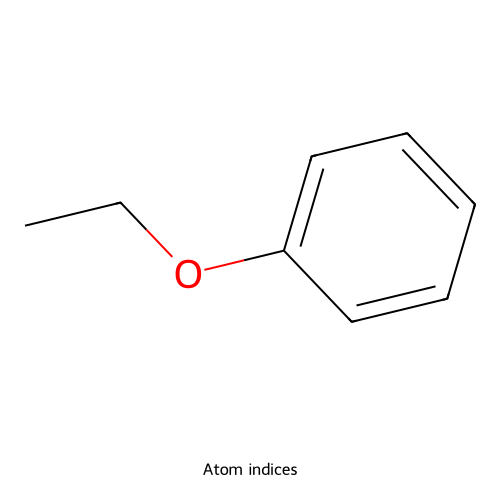

In [134]:
from rdkit.Chem import Draw

mol = Chem.MolFromSmiles("CCOc1ccccc1")

Draw.MolToImage(
    mol,
    size=(500, 500),
    kekulize=True,
    legend="Atom indices"
)

In [136]:
from rdkit.Chem.Draw import rdMolDraw2D

drawer = rdMolDraw2D.MolDraw2DCairo(600, 500)

drawer.drawOptions().addAtomIndices = True

drawer.DrawMolecule(mol)
drawer.FinishDrawing()

img = drawer.GetDrawingText()

with open("atom_indices.png", "wb") as f:
    f.write(img)

### 12. Bonds

* Bond type
* Single
* Double
* Triple
* Aromatic
* Bond order
* Ring bond
* Conjugation


In [137]:
bond_records = []

for idx, row in data.iterrows():

    if mol is None:
        raise ValueError("Invalid molecule")

    mol = row["mol"]

    for bond in mol.GetBonds():

        bond_records.append({
            "compound_id": row["Compound ID"],
            "smiles": row["smiles"],

            "bond_index": bond.GetIdx(),

            "begin_atom": bond.GetBeginAtomIdx(),
            "end_atom": bond.GetEndAtomIdx(),

            "begin_element": bond.GetBeginAtom().GetSymbol(),
            "end_element": bond.GetEndAtom().GetSymbol(),

            "bond_type": str(bond.GetBondType()),
            "bond_order": bond.GetBondTypeAsDouble(),

            "aromatic": bond.GetIsAromatic(),
            "ring_bond": bond.IsInRing(),
            "conjugated": bond.GetIsConjugated(),
        })

bond_dataset = pd.DataFrame(bond_records)

In [138]:
bond_dataset.head(20)

,compound_id,smiles,bond_index,begin_atom,end_atom,begin_element,end_element,bond_type,bond_order,aromatic,ring_bond,conjugated
0,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,0,0,1,O,C,SINGLE,1.0,False,False,False
1,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,1,1,2,C,C,SINGLE,1.0,False,False,False
2,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,2,2,3,C,O,SINGLE,1.0,False,True,False
3,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,3,3,4,O,C,SINGLE,1.0,False,True,False
4,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,4,4,5,C,O,SINGLE,1.0,False,False,False
5,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,5,5,6,O,C,SINGLE,1.0,False,False,False
6,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,6,6,7,C,C,SINGLE,1.0,False,False,False
7,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,7,7,8,C,O,SINGLE,1.0,False,True,False
8,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,8,8,9,O,C,SINGLE,1.0,False,True,False
9,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,9,9,10,C,O,SINGLE,1.0,False,False,False


In [140]:
# Explore Bonds

import pandas as pd
from rdkit import Chem


def explore_bonds(mol):

    if mol is None:
        raise ValueError("Invalid molecule")

    bonds = []

    for bond in mol.GetBonds():

        bonds.append({
            "Bond Index": bond.GetIdx(),

            "Begin Atom": bond.GetBeginAtomIdx(),

            "End Atom": bond.GetEndAtomIdx(),

            "Begin Element":
                bond.GetBeginAtom().GetSymbol(),

            "End Element":
                bond.GetEndAtom().GetSymbol(),

            "Bond Type":
                str(bond.GetBondType()),

            "Bond Order":
                bond.GetBondTypeAsDouble(),

            "Single":
                bond.GetBondType() == Chem.BondType.SINGLE,

            "Double":
                bond.GetBondType() == Chem.BondType.DOUBLE,

            "Triple":
                bond.GetBondType() == Chem.BondType.TRIPLE,

            "Aromatic":
                bond.GetIsAromatic(),

            "Ring Bond":
                bond.IsInRing(),

            "Conjugated":
                bond.GetIsConjugated()
        })

    return pd.DataFrame(bonds)

In [141]:
mol = Chem.MolFromSmiles(
    "CC(=O)Oc1ccccc1C(=O)O"
)

bond_df = explore_bonds(mol)

display(bond_df)

,Bond Index,Begin Atom,End Atom,Begin Element,End Element,Bond Type,Bond Order,Single,Double,Triple,Aromatic,Ring Bond,Conjugated
0,0,0,1,C,C,SINGLE,1.0,True,False,False,False,False,False
1,1,1,2,C,O,DOUBLE,2.0,False,True,False,False,False,True
2,2,1,3,C,O,SINGLE,1.0,True,False,False,False,False,True
3,3,3,4,O,C,SINGLE,1.0,True,False,False,False,False,True
4,4,4,5,C,C,AROMATIC,1.5,False,False,False,True,True,True
5,5,5,6,C,C,AROMATIC,1.5,False,False,False,True,True,True
6,6,6,7,C,C,AROMATIC,1.5,False,False,False,True,True,True
7,7,7,8,C,C,AROMATIC,1.5,False,False,False,True,True,True
8,8,8,9,C,C,AROMATIC,1.5,False,False,False,True,True,True
9,9,9,10,C,C,SINGLE,1.0,True,False,False,False,False,True


### 15. Elements

> Calculate element frequencies.

`	ext
C
N
O
S
P
F
Cl
Br
I
...
`


In [142]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

In [143]:
# Count elements in one molecule

def get_molecule_elements(mol):

    if mol is None:
        return []

    return [
        atom.GetSymbol()
        for atom in mol.GetAtoms()
    ]

In [144]:
# Example molecule

example_mol = data["mol"].dropna().iloc[0]

example_elements = get_molecule_elements(
    example_mol
)

print("Elements in example molecule:")
print(example_elements)


Elements in example molecule:
['O', 'C', 'C', 'O', 'C', 'O', 'C', 'C', 'O', 'C', 'O', 'C', 'C', 'N', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'O', 'C', 'O', 'C', 'O', 'C', 'O', 'C', 'O', 'C', 'O']


In [145]:
#Element frequency across the entire dataset

element_counter = Counter()

for mol in data["mol"].dropna():

    element_counter.update(
        get_molecule_elements(mol)
    )

In [146]:
# Convert frequency to DataFrame

element_df = (
    pd.DataFrame(
        element_counter.items(),
        columns=["Element", "Frequency"]
    )
    .sort_values(
        "Frequency",
        ascending=False
    )
    .reset_index(drop=True)
)


In [147]:
# Calculate percentage

element_df["Percentage"] = (
    element_df["Frequency"]
    / element_df["Frequency"].sum()
    * 100
)

In [148]:
# Display all elements

print("=" * 60)
print("ELEMENT FREQUENCY")
print("=" * 60)

display(
    element_df.round({
        "Percentage": 2
    })
)

ELEMENT FREQUENCY


,Element,Frequency,Percentage
0,C,11089,74.79
1,O,1741,11.74
2,N,960,6.47
3,Cl,640,4.32
4,S,164,1.11
5,F,100,0.67
6,Br,71,0.48
7,P,44,0.30
8,I,18,0.12


In [149]:
# Check the requested elements

requested_elements = [
    "C",
    "N",
    "O",
    "S",
    "P",
    "F",
    "Cl",
    "Br",
    "I"
]

requested_df = element_df[
    element_df["Element"].isin(
        requested_elements
    )
].copy()

print("=" * 60)
print("REQUESTED ELEMENTS")
print("=" * 60)

display(
    requested_df.round({
        "Percentage": 2
    })
)


REQUESTED ELEMENTS


,Element,Frequency,Percentage
0,C,11089,74.79
1,O,1741,11.74
2,N,960,6.47
3,Cl,640,4.32
4,S,164,1.11
5,F,100,0.67
6,Br,71,0.48
7,P,44,0.30
8,I,18,0.12


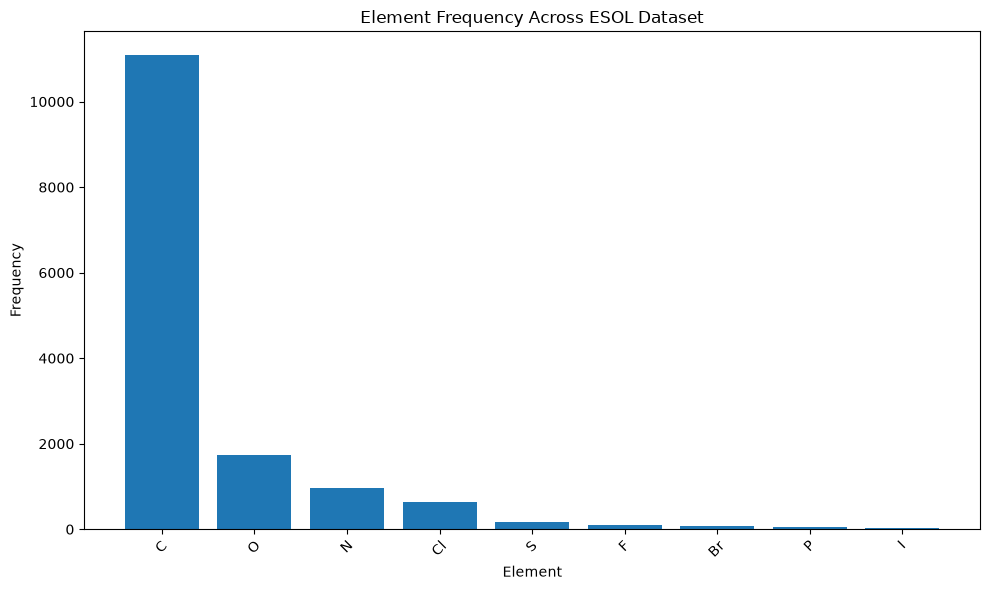

In [150]:
# Plot element frequencies

plt.figure(figsize=(10, 6))

plt.bar(
    element_df["Element"],
    element_df["Frequency"]
)

plt.xlabel("Element")
plt.ylabel("Frequency")
plt.title("Element Frequency Across ESOL Dataset")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [151]:
# Count how many molecules contain each element

molecule_element_counter = Counter()

for mol in data["mol"].dropna():

    unique_elements = set(
        get_molecule_elements(mol)
    )

    molecule_element_counter.update(
        unique_elements
    )


molecule_element_df = (
    pd.DataFrame(
        molecule_element_counter.items(),
        columns=[
            "Element",
            "Molecule_Count"
        ]
    )
    .sort_values(
        "Molecule_Count",
        ascending=False
    )
    .reset_index(drop=True)
)

In [152]:
# Molecule percentage

valid_molecule_count = data["mol"].notna().sum()

molecule_element_df["Percentage"] = (
    molecule_element_df["Molecule_Count"]
    / valid_molecule_count
    * 100
)


print("=" * 60)
print("MOLECULES CONTAINING EACH ELEMENT")
print("=" * 60)

display(
    molecule_element_df.round({
        "Percentage": 2
    })
)

MOLECULES CONTAINING EACH ELEMENT


,Element,Molecule_Count,Percentage
0,C,1117,100.00
1,O,716,64.10
2,N,452,40.47
3,Cl,250,22.38
4,S,115,10.30
5,Br,49,4.39
6,F,44,3.94
7,P,42,3.76
8,I,16,1.43


In [153]:
# Compare frequency vs molecule count

element_analysis = element_df.merge(
    molecule_element_df,
    on="Element",
    how="outer"
)

print("=" * 60)
print("COMPLETE ELEMENT ANALYSIS")
print("=" * 60)

display(
    element_analysis.round({
        "Percentage_x": 2,
        "Percentage_y": 2
    })
)

COMPLETE ELEMENT ANALYSIS


,Element,Frequency,Percentage_x,Molecule_Count,Percentage_y
0,Br,71,0.48,49,4.39
1,C,11089,74.79,1117,100.00
2,Cl,640,4.32,250,22.38
3,F,100,0.67,44,3.94
4,I,18,0.12,16,1.43
5,N,960,6.47,452,40.47
6,O,1741,11.74,716,64.10
7,P,44,0.30,42,3.76
8,S,164,1.11,115,10.30


### 16. Formal Charge

* Neutral molecules
* Cations
* Anions
* Charged atoms


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem

In [154]:
# Calculate molecular formal charge

def get_formal_charge(mol):

    if mol is None:
        return None

    return Chem.GetFormalCharge(mol)


# Calculate atom-level charges

def get_charged_atoms(mol):

    if mol is None:
        return []

    charged_atoms = []

    for atom in mol.GetAtoms():

        charge = atom.GetFormalCharge()

        if charge != 0:

            charged_atoms.append({
                "Atom_Index": atom.GetIdx(),
                "Element": atom.GetSymbol(),
                "Formal_Charge": charge
            })

    return charged_atoms

In [155]:
# Calculate molecular charge

valid_data = data[data["mol"].notna()].copy()

valid_data["Formal_Charge"] = valid_data["mol"].apply(
    get_formal_charge
)

In [156]:
# Classify molecules

def classify_charge(charge):

    if charge == 0:
        return "Neutral"

    elif charge > 0:
        return "Cation"

    else:
        return "Anion"


valid_data["Charge_Class"] = valid_data[
    "Formal_Charge"
].apply(classify_charge)

In [157]:
# Display molecular charge

print("=" * 70)
print("MOLECULAR FORMAL CHARGE")
print("=" * 70)

display(
    valid_data[
        [
            "Compound ID",
            "smiles",
            "Formal_Charge",
            "Charge_Class"
        ]
    ].head(20)
)

MOLECULAR FORMAL CHARGE


,Compound ID,smiles,Formal_Charge,Charge_Class
0,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,0,Neutral
1,Fenfuram,Cc1occc1C(=O)Nc1ccccc1,0,Neutral
2,citral,CC(C)=CCCC(C)=CC=O,0,Neutral
3,Picene,c1ccc2c(c1)ccc1c2ccc2c3ccccc3ccc21,0,Neutral
4,Thiophene,c1ccsc1,0,Neutral
5,benzothiazole,c1ccc2scnc2c1,0,Neutral
6,"2,2,4,6,6'-PCB",Clc1cc(Cl)c(-c2c(Cl)cccc2Cl)c(Cl)c1,0,Neutral
7,Estradiol,CC12CCC3c4ccc(O)cc4CCC3C1CCC2O,0,Neutral
8,Dieldrin,ClC1=C(Cl)C2(Cl)C3C4CC(C5OC45)C3C1(Cl)C2(Cl)Cl,0,Neutral
9,Rotenone,C=C(C)C1Cc2c(ccc3c2OC2COc4cc(OC)c(OC)cc4C2C3=O)O1,0,Neutral


In [158]:
# Charge class frequency

charge_counts = (
    valid_data["Charge_Class"]
    .value_counts()
)


print("=" * 70)
print("CHARGE CLASS DISTRIBUTION")
print("=" * 70)

display(
    charge_counts.to_frame(
        "Molecule_Count"
    )
)


CHARGE CLASS DISTRIBUTION


,Molecule_Count
Charge_Class,
Neutral,1117


In [159]:
# Charge class percentage

charge_summary = pd.DataFrame({
    "Molecule_Count": charge_counts
})

charge_summary["Percentage"] = (
    charge_summary["Molecule_Count"]
    / len(valid_data)
    * 100
)

print("=" * 70)
print("CHARGE SUMMARY")
print("=" * 70)

display(
    charge_summary.round(2)
)

CHARGE SUMMARY


,Molecule_Count,Percentage
Charge_Class,,
Neutral,1117,100.0


In [160]:
# Neutral molecules

neutral_molecules = valid_data[
    valid_data["Formal_Charge"] == 0
]

print("=" * 70)
print("NEUTRAL MOLECULES")
print("=" * 70)

print(
    "Count:",
    len(neutral_molecules)
)

display(
    neutral_molecules[
        [
            "Compound ID",
            "smiles",
            "Formal_Charge"
        ]
    ].head(20)
)

NEUTRAL MOLECULES
Count: 1117


,Compound ID,smiles,Formal_Charge
0,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,0
1,Fenfuram,Cc1occc1C(=O)Nc1ccccc1,0
2,citral,CC(C)=CCCC(C)=CC=O,0
3,Picene,c1ccc2c(c1)ccc1c2ccc2c3ccccc3ccc21,0
4,Thiophene,c1ccsc1,0
5,benzothiazole,c1ccc2scnc2c1,0
6,"2,2,4,6,6'-PCB",Clc1cc(Cl)c(-c2c(Cl)cccc2Cl)c(Cl)c1,0
7,Estradiol,CC12CCC3c4ccc(O)cc4CCC3C1CCC2O,0
8,Dieldrin,ClC1=C(Cl)C2(Cl)C3C4CC(C5OC45)C3C1(Cl)C2(Cl)Cl,0
9,Rotenone,C=C(C)C1Cc2c(ccc3c2OC2COc4cc(OC)c(OC)cc4C2C3=O)O1,0


In [161]:
# Cations

cations = valid_data[
    valid_data["Formal_Charge"] > 0
]

print("=" * 70)
print("CATIONS")
print("=" * 70)

print(
    "Count:",
    len(cations)
)

display(
    cations[
        [
            "Compound ID",
            "smiles",
            "Formal_Charge"
        ]
    ].head(20)
)

CATIONS
Count: 0


,Compound ID,smiles,Formal_Charge


In [162]:
# Anions

anions = valid_data[
    valid_data["Formal_Charge"] < 0
]

print("=" * 70)
print("ANIONS")
print("=" * 70)

print(
    "Count:",
    len(anions)
)

display(
    anions[
        [
            "Compound ID",
            "smiles",
            "Formal_Charge"
        ]
    ].head(20)
)

ANIONS
Count: 0


,Compound ID,smiles,Formal_Charge


In [163]:
# Charged atoms across the dataset

charged_atom_records = []

for _, row in valid_data.iterrows():

    mol = row["mol"]

    for atom in mol.GetAtoms():

        charge = atom.GetFormalCharge()

        if charge != 0:

            charged_atom_records.append({

                "Compound ID":
                    row["Compound ID"],

                "SMILES":
                    row["smiles"],

                "Atom_Index":
                    atom.GetIdx(),

                "Element":
                    atom.GetSymbol(),

                "Formal_Charge":
                    charge
            })


charged_atoms_df = pd.DataFrame(
    charged_atom_records
)


print("=" * 70)
print("CHARGED ATOMS")
print("=" * 70)

if len(charged_atoms_df) > 0:

    display(
        charged_atoms_df.head(30)
    )

else:

    print(
        "No charged atoms found in the dataset."
    )

CHARGED ATOMS


,Compound ID,SMILES,Atom_Index,Element,Formal_Charge
0,Dinitramine,CCN(CC)c1c([N+](=O)[O-])cc(C(F)(F)F)c(N)c1[N+]...,12,N,1
1,Dinitramine,CCN(CC)c1c([N+](=O)[O-])cc(C(F)(F)F)c(N)c1[N+]...,13,O,-1
2,Dinitramine,CCN(CC)c1c([N+](=O)[O-])cc(C(F)(F)F)c(N)c1[N+]...,19,N,1
3,Dinitramine,CCN(CC)c1c([N+](=O)[O-])cc(C(F)(F)F)c(N)c1[N+]...,20,O,-1
4,nifedipine,COC(=O)C1=C(C)NC(C)=C(C(=O)OC)C1c1ccccc1[N+](=...,17,N,1
5,nifedipine,COC(=O)C1=C(C)NC(C)=C(C(=O)OC)C1c1ccccc1[N+](=...,18,O,-1
6,Benznidazole,O=C(Cn1ccnc1[N+](=O)[O-])NCc1ccccc1,8,N,1
7,Benznidazole,O=C(Cn1ccnc1[N+](=O)[O-])NCc1ccccc1,9,O,-1
8,nitrofurantoin,O=C1CN(N=Cc2ccc([N+](=O)[O-])o2)C(=O)N1,11,N,1
9,nitrofurantoin,O=C1CN(N=Cc2ccc([N+](=O)[O-])o2)C(=O)N1,12,O,-1


In [164]:
# Charged atom element frequency

if len(charged_atoms_df) > 0:

    charged_atom_frequency = (
        charged_atoms_df["Element"]
        .value_counts()
        .rename_axis("Element")
        .reset_index(
            name="Charged_Atom_Count"
        )
    )

    print("=" * 70)
    print("CHARGED ATOM ELEMENT FREQUENCY")
    print("=" * 70)

    display(
        charged_atom_frequency
    )


CHARGED ATOM ELEMENT FREQUENCY


,Element,Charged_Atom_Count
0,N,78
1,O,78


In [165]:
# Positive vs negative atoms

if len(charged_atoms_df) > 0:

    positive_atoms = charged_atoms_df[
        charged_atoms_df["Formal_Charge"] > 0
    ]

    negative_atoms = charged_atoms_df[
        charged_atoms_df["Formal_Charge"] < 0
    ]

    print("=" * 70)
    print("ATOM CHARGE SUMMARY")
    print("=" * 70)

    print(
        "Positive charged atoms:",
        len(positive_atoms)
    )

    print(
        "Negative charged atoms:",
        len(negative_atoms)
    )

ATOM CHARGE SUMMARY
Positive charged atoms: 78
Negative charged atoms: 78


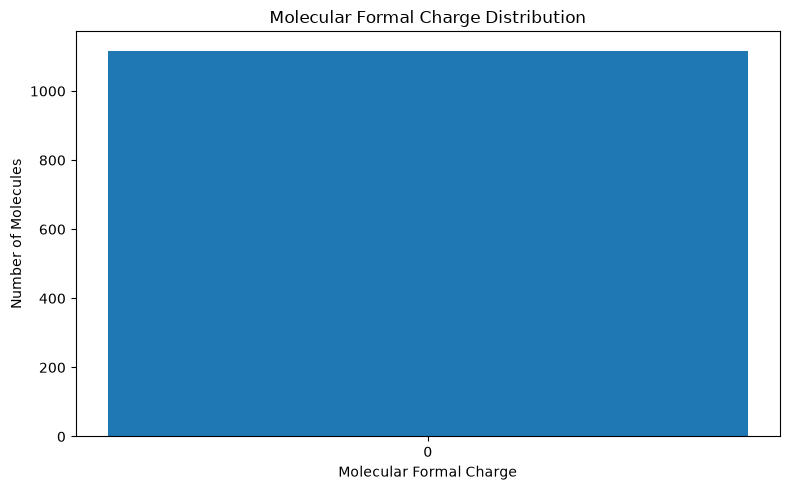

In [166]:
# Molecular charge distribution

plt.figure(figsize=(8, 5))

charge_frequency = (
    valid_data["Formal_Charge"]
    .value_counts()
    .sort_index()
)

plt.bar(
    charge_frequency.index.astype(str),
    charge_frequency.values
)

plt.xlabel("Molecular Formal Charge")
plt.ylabel("Number of Molecules")
plt.title("Molecular Formal Charge Distribution")

plt.tight_layout()
plt.show()

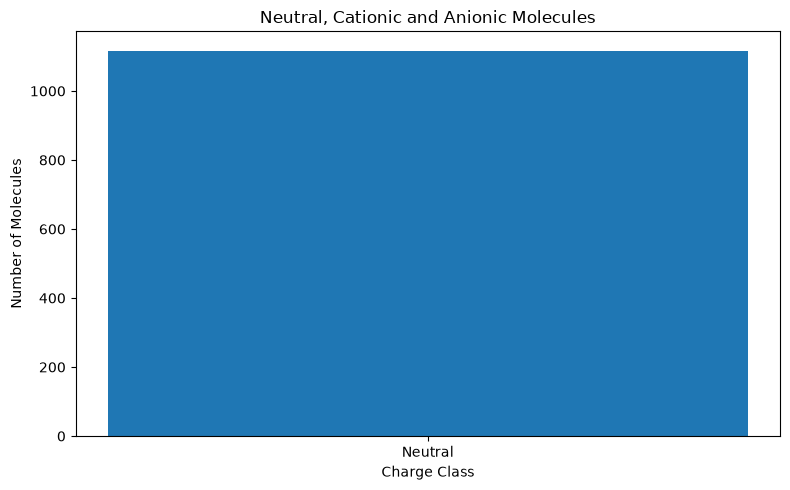

In [169]:
# Charge class visualization

plt.figure(figsize=(8, 5))

plt.bar(
    charge_summary.index,
    charge_summary["Molecule_Count"]
)

plt.xlabel("Charge Class")
plt.ylabel("Number of Molecules")
plt.title("Neutral, Cationic and Anionic Molecules")

plt.tight_layout()
plt.show()

In [168]:
# Final charge feature matrix

charge_feature_matrix = valid_data[
    [
        "Compound ID",
        "smiles",
        "Formal_Charge",
        "Charge_Class"
    ]
].copy()


print("=" * 70)
print("FINAL CHARGE FEATURE MATRIX")
print("=" * 70)

print(
    "Shape:",
    charge_feature_matrix.shape
)

display(
    charge_feature_matrix.head(10)
)

FINAL CHARGE FEATURE MATRIX
Shape: (1117, 4)


,Compound ID,smiles,Formal_Charge,Charge_Class
0,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,0,Neutral
1,Fenfuram,Cc1occc1C(=O)Nc1ccccc1,0,Neutral
2,citral,CC(C)=CCCC(C)=CC=O,0,Neutral
3,Picene,c1ccc2c(c1)ccc1c2ccc2c3ccccc3ccc21,0,Neutral
4,Thiophene,c1ccsc1,0,Neutral
5,benzothiazole,c1ccc2scnc2c1,0,Neutral
6,"2,2,4,6,6'-PCB",Clc1cc(Cl)c(-c2c(Cl)cccc2Cl)c(Cl)c1,0,Neutral
7,Estradiol,CC12CCC3c4ccc(O)cc4CCC3C1CCC2O,0,Neutral
8,Dieldrin,ClC1=C(Cl)C2(Cl)C3C4CC(C5OC45)C3C1(Cl)C2(Cl)Cl,0,Neutral
9,Rotenone,C=C(C)C1Cc2c(ccc3c2OC2COc4cc(OC)c(OC)cc4C2C3=O)O1,0,Neutral


### 17. Aromaticity

* Aromatic atoms
* Aromatic bonds
* Aromatic systems


### 20. Molecular Visualization & Export

`	ext
PNG
SVG
`


### 23. Basic Descriptors

`	ext
MW
LogP
TPSA
HBD
HBA
Rotatable Bonds
Heavy Atom Count
Ring Count
Aromatic Ring Count
Fraction Csp3
Formal Charge
MolMR
`


In [170]:
from rdkit import Chem
from rdkit.Chem import (
    Descriptors,
    Crippen,
    Lipinski,
    rdMolDescriptors
)


def calculate_basic_descriptors(mol):

    if mol is None:
        return None

    return {
        "MW": Descriptors.MolWt(mol),

        "LogP": Crippen.MolLogP(mol),

        "TPSA": rdMolDescriptors.CalcTPSA(mol),

        "HBD": Lipinski.NumHDonors(mol),

        "HBA": Lipinski.NumHAcceptors(mol),

        "Rotatable_Bonds": (
            Lipinski.NumRotatableBonds(mol)
        ),

        "Heavy_Atom_Count": (
            Lipinski.HeavyAtomCount(mol)
        ),

        "Ring_Count": (
            rdMolDescriptors.CalcNumRings(mol)
        ),

        "Aromatic_Ring_Count": (
            rdMolDescriptors.CalcNumAromaticRings(mol)
        ),

        "Fraction_Csp3": (
            rdMolDescriptors.CalcFractionCSP3(mol)
        ),

        "Formal_Charge": (
            Chem.GetFormalCharge(mol)
        ),

        "MolMR": Crippen.MolMR(mol)
    }

In [171]:
descriptor_results = valid_data["mol"].apply(
    calculate_basic_descriptors
)

descriptor_df = pd.DataFrame(
    descriptor_results.tolist(),
    index=valid_data.index
)

In [172]:
descriptor_df.head()

,MW,LogP,TPSA,HBD,HBA,Rotatable_Bonds,Heavy_Atom_Count,Ring_Count,Aromatic_Ring_Count,Fraction_Csp3,Formal_Charge,MolMR
0,457.432,-3.10802,202.32,7,12,7,32,3,1,0.650000,0,102.2816
1,201.225,2.84032,42.24,1,2,2,15,2,2,0.083333,0,57.8402
2,152.237,2.87800,17.07,0,1,4,11,0,0,0.500000,0,48.4860
3,278.354,6.29940,0.00,0,0,0,22,5,5,0.000000,0,96.4660
4,84.143,1.74810,0.00,0,1,0,5,1,1,0.000000,0,24.3190


In [176]:
# Descriptor Summary

basic_descriptor_columns = [
    "MW",
    "LogP",
    "TPSA",
    "HBD",
    "HBA",
    "Rotatable_Bonds",
    "Heavy_Atom_Count",
    "Ring_Count",
    "Aromatic_Ring_Count",
    "Fraction_Csp3",
    "Formal_Charge",
    "MolMR"
]

descriptor_summary = (
    descriptor_df[basic_descriptor_columns]
    .describe()
    .T
)

display(descriptor_summary)

,count,mean,std,min,25%,50%,75%,max
MW,1117.0,203.707382,102.944082,16.0430,120.62300,182.172000,270.3720,780.9490
LogP,1117.0,2.453439,1.845119,-7.5714,1.41762,2.339200,3.3918,10.3886
TPSA,1117.0,34.714772,35.328532,0.0000,0.00000,26.020000,55.1200,268.6800
HBD,1117.0,0.694718,1.080496,0.0000,0.00000,0.000000,1.0000,11.0000
HBA,1117.0,2.062668,2.109802,0.0000,0.00000,2.000000,3.0000,16.0000
Rotatable_Bonds,1117.0,2.173679,2.643431,0.0000,0.00000,1.000000,3.0000,23.0000
Heavy_Atom_Count,1117.0,13.273948,6.897494,1.0000,8.00000,12.000000,18.0000,55.0000
Ring_Count,1117.0,1.387645,1.320214,0.0000,0.00000,1.000000,2.0000,8.0000
Aromatic_Ring_Count,1117.0,0.932856,1.007127,0.0000,0.00000,1.000000,2.0000,7.0000
Fraction_Csp3,1117.0,0.443574,0.375130,0.0000,0.10000,0.352941,0.8000,1.0000


### 24. EState Descriptors


In [178]:
import numpy as np
import pandas as pd

from rdkit import Chem
from rdkit.Chem import EState

In [179]:
# Display atom-level EState for one example molecule

example_idx = valid_data.index[0]

example_mol = valid_data.loc[
    example_idx,
    "mol"
]

example_estate = EState.EStateIndices(
    example_mol
)

example_types = EState.TypeAtoms(
    example_mol
)


atom_estate_df = pd.DataFrame({
    "Atom_Index": [
        atom.GetIdx()
        for atom in example_mol.GetAtoms()
    ],

    "Element": [
        atom.GetSymbol()
        for atom in example_mol.GetAtoms()
    ],

    "Atomic_Number": [
        atom.GetAtomicNum()
        for atom in example_mol.GetAtoms()
    ],

    "Degree": [
        atom.GetDegree()
        for atom in example_mol.GetAtoms()
    ],

    "Hybridization": [
        str(atom.GetHybridization())
        for atom in example_mol.GetAtoms()
    ],

    "Formal_Charge": [
        atom.GetFormalCharge()
        for atom in example_mol.GetAtoms()
    ],

    "Aromatic": [
        atom.GetIsAromatic()
        for atom in example_mol.GetAtoms()
    ],

    "Ring_Member": [
        atom.IsInRing()
        for atom in example_mol.GetAtoms()
    ],

    "Hydrogens": [
        atom.GetTotalNumHs()
        for atom in example_mol.GetAtoms()
    ],

    "EState_Type": example_types,

    "EState": example_estate
})

In [ ]:
# Display example atom-level EState analysis
print("=" * 70)
print("ATOM-LEVEL EState ANALYSIS")
print("=" * 70)

print(
    "Compound:",
    valid_data.loc[example_idx, "Compound ID"]
)

print(
    "SMILES:",
    valid_data.loc[example_idx, "smiles"]
)

display(atom_estate_df)

ATOM-LEVEL EState ANALYSIS
Compound: Amigdalin
SMILES: N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c1ccccc1


,Atom_Index,Element,Atomic_Number,Degree,Hybridization,Formal_Charge,Aromatic,Ring_Member,Hydrogens,EState_Type,EState
0,0,O,8,1,SP3,0,False,False,1,"(sOH,)",9.240391
1,1,C,6,2,SP3,0,False,False,2,"(ssCH2,)",-0.649588
2,2,C,6,3,SP3,0,False,True,1,"(sssCH,)",-1.220971
3,3,O,8,2,SP3,0,False,True,0,"(ssO,)",5.215822
4,4,C,6,3,SP3,0,False,True,1,"(sssCH,)",-1.485290
5,5,O,8,2,SP3,0,False,False,0,"(ssO,)",5.351038
6,6,C,6,2,SP3,0,False,False,2,"(ssCH2,)",-0.490025
7,7,C,6,3,SP3,0,False,True,1,"(sssCH,)",-1.276958
8,8,O,8,2,SP3,0,False,True,0,"(ssO,)",5.505835
9,9,C,6,3,SP3,0,False,True,1,"(sssCH,)",-1.498466


In [181]:
# EState descriptor calculation for one molecule

def calculate_estate_descriptors(mol):
    """
    Calculate atom-level EState values and
    aggregate them into molecule-level descriptors.
    """

    if mol is None:
        return None

    # Atom-level EState indices
    estate_values = np.asarray(
        EState.EStateIndices(mol),
        dtype=float
    )

    # EState atom types
    estate_types = EState.TypeAtoms(mol)

    # Aggregate molecular-level EState descriptors
    result = {
        "EState_Sum": np.sum(estate_values),
        "EState_Mean": np.mean(estate_values),
        "EState_Min": np.min(estate_values),
        "EState_Max": np.max(estate_values),
        "EState_Std": np.std(estate_values),
        "EState_Range": np.ptp(estate_values),

        # Keep the original atom-level representation
        "EState_Values": estate_values.tolist(),
        "EState_Atom_Types": estate_types
    }

    return result

In [185]:
# Convert molecular-level EState descriptors to DataFrame

estate_results = valid_data["mol"].apply(
    calculate_estate_descriptors
)

estate_df = pd.DataFrame(
    estate_results.tolist(),
    index=valid_data.index
)

display(estate_df.head())

,EState_Sum,EState_Mean,EState_Min,EState_Max,EState_Std,EState_Range,EState_Values,EState_Atom_Types
0,93.833333,2.932292,-1.701605,10.253329,4.567198,11.954934,"[9.240390717985553, -0.6495883381425269, -1.22...","[(sOH,), (ssCH2,), (sssCH,), (ssO,), (sssCH,),..."
1,35.666667,2.377778,-0.145880,11.724911,2.744184,11.870791,"[1.7637962962962963, 0.6281769652305369, 5.062...","[(sCH3,), (aasC,), (aaO,), (aaCH,), (aaCH,), (..."
2,25.333333,2.303030,0.845090,10.020498,2.485294,9.175408,"[2.0821141975308644, 1.3369472789115648, 2.082...","[(sCH3,), (dssC,), (sCH3,), (dsCH,), (ssCH2,),..."
3,41.333333,1.878788,1.301055,2.270278,0.421738,0.969223,"[2.0999225770555134, 2.1174225770555135, 2.212...","[(aaCH,), (aaCH,), (aaCH,), (aaaC,), (aaaC,), ..."
4,9.833333,1.966667,1.712963,2.041667,0.127274,0.328704,"[2.0185185185185186, 2.0185185185185186, 2.041...","[(aaCH,), (aaCH,), (aaCH,), (aaS,), (aaCH,)]"


In [186]:
# Add molecular-level EState descriptors to dataset

valid_data = pd.concat(
    [
        valid_data,
        estate_df[
            [
                "EState_Sum",
                "EState_Mean",
                "EState_Min",
                "EState_Max",
                "EState_Std",
                "EState_Range"
            ]
        ]
    ],
    axis=1
)

display(
    valid_data[
        [
            "Compound ID",
            "smiles",
            "EState_Sum",
            "EState_Mean",
            "EState_Min",
            "EState_Max",
            "EState_Std",
            "EState_Range"
        ]
    ].head()
)

,Compound ID,smiles,EState_Sum,EState_Mean,EState_Min,EState_Max,EState_Std,EState_Range
0,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,93.833333,2.932292,-1.701605,10.253329,4.567198,11.954934
1,Fenfuram,Cc1occc1C(=O)Nc1ccccc1,35.666667,2.377778,-0.145880,11.724911,2.744184,11.870791
2,citral,CC(C)=CCCC(C)=CC=O,25.333333,2.303030,0.845090,10.020498,2.485294,9.175408
3,Picene,c1ccc2c(c1)ccc1c2ccc2c3ccccc3ccc21,41.333333,1.878788,1.301055,2.270278,0.421738,0.969223
4,Thiophene,c1ccsc1,9.833333,1.966667,1.712963,2.041667,0.127274,0.328704


In [187]:
# Display molecular-level EState descriptors

print("=" * 70)
print("MOLECULAR-LEVEL EState DESCRIPTORS")
print("=" * 70)

molecular_estate_columns = [
    "Compound ID",
    "smiles",
    "EState_Sum",
    "EState_Mean",
    "EState_Min",
    "EState_Max",
    "EState_Std",
    "EState_Range"
]

display(
    valid_data[molecular_estate_columns].head(10)
)

MOLECULAR-LEVEL EState DESCRIPTORS


,Compound ID,smiles,EState_Sum,EState_Mean,EState_Min,EState_Max,EState_Std,EState_Range
0,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,93.833333,2.932292,-1.701605,10.253329,4.567198,11.954934
1,Fenfuram,Cc1occc1C(=O)Nc1ccccc1,35.666667,2.377778,-0.145880,11.724911,2.744184,11.870791
2,citral,CC(C)=CCCC(C)=CC=O,25.333333,2.303030,0.845090,10.020498,2.485294,9.175408
3,Picene,c1ccc2c(c1)ccc1c2ccc2c3ccccc3ccc21,41.333333,1.878788,1.301055,2.270278,0.421738,0.969223
4,Thiophene,c1ccsc1,9.833333,1.966667,1.712963,2.041667,0.127274,0.328704
5,benzothiazole,c1ccc2scnc2c1,18.166667,2.018519,1.099537,4.137222,0.819935,3.037685
6,"2,2,4,6,6'-PCB",Clc1cc(Cl)c(-c2c(Cl)cccc2Cl)c(Cl)c1,42.222222,2.483660,0.414352,6.127096,2.365990,5.712744
7,Estradiol,CC12CCC3c4ccc(O)cc4CCC3C1CCC2O,40.583333,2.029167,-0.088273,10.372487,2.735766,10.460760
8,Dieldrin,ClC1=C(Cl)C2(Cl)C3C4CC(C5OC45)C3C1(Cl)C2(Cl)Cl,44.750000,2.355263,-1.374691,6.824159,3.194439,8.198850
9,Rotenone,C=C(C)C1Cc2c(ccc3c2OC2COc4cc(OC)c(OC)cc4C2C3=O)O1,65.166667,2.247126,-0.455218,13.517073,2.926856,13.972291


In [188]:
# Statistical summary

print("=" * 70)
print("EState STATISTICAL SUMMARY")
print("=" * 70)

estate_summary = (
    valid_data[
        [
            "EState_Sum",
            "EState_Mean",
            "EState_Min",
            "EState_Max",
            "EState_Std",
            "EState_Range"
        ]
    ]
    .describe()
    .T
)

display(estate_summary)

EState STATISTICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
EState_Sum,1117.0,32.588972,18.360635,0.00000,17.833333,29.333333,43.333333,128.583333
EState_Mean,1117.0,2.447472,0.506133,0.00000,2.100000,2.377193,2.736111,5.340278
EState_Min,1117.0,-0.176905,1.296589,-5.57322,-0.597086,-0.043158,0.743889,4.000000
EState_Max,1117.0,8.225498,3.712433,0.00000,5.024306,9.188056,11.446157,17.262020
EState_Std,1117.0,2.537582,1.369561,0.00000,1.393821,2.702271,3.414272,6.500016
EState_Range,1117.0,8.402404,4.674714,0.00000,4.533179,9.132603,12.003690,19.447140


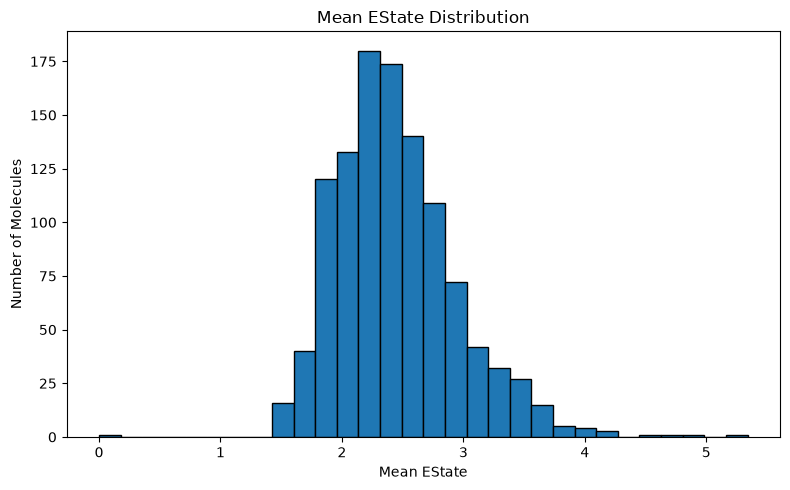

In [189]:
# visualize EState Distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    valid_data["EState_Mean"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Mean EState")
plt.ylabel("Number of Molecules")
plt.title("Mean EState Distribution")

plt.tight_layout()
plt.show()

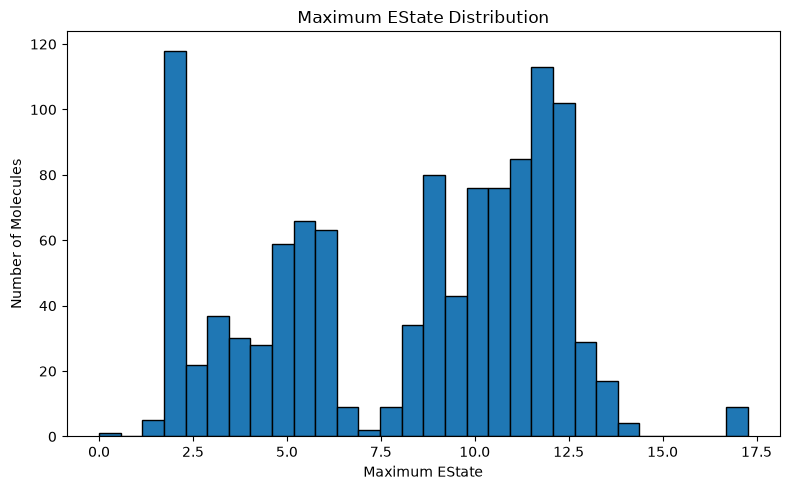

In [190]:
plt.figure(figsize=(8, 5))

plt.hist(
    valid_data["EState_Max"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Maximum EState")
plt.ylabel("Number of Molecules")
plt.title("Maximum EState Distribution")

plt.tight_layout()
plt.show()

### 25. Chi Descriptors


In [ ]:
from rdkit.Chem import GraphDescriptors

In [ ]:
# Calculate Chi descriptors for one molecule
def calculate_chi_descriptors(mol):

    if mol is None:
        return None

    return {
        # Standard Chi connectivity indices
        "Chi0": GraphDescriptors.Chi0(mol),
        "Chi1": GraphDescriptors.Chi1(mol),
        "Chi2": GraphDescriptors.Chi2(mol),

        # Normalized / valence variants
        "Chi0n": GraphDescriptors.Chi0n(mol),
        "Chi1n": GraphDescriptors.Chi1n(mol),
        "Chi2n": GraphDescriptors.Chi2n(mol),

        "Chi0v": GraphDescriptors.Chi0v(mol),
        "Chi1v": GraphDescriptors.Chi1v(mol),
        "Chi2v": GraphDescriptors.Chi2v(mol),
    }

In [195]:
from rdkit.Chem import GraphDescriptors

mol = data["mol"].dropna().iloc[0]

print("Chi0 :", GraphDescriptors.Chi0(mol))
print("Chi1 :", GraphDescriptors.Chi1(mol))
print("Chi2 :", GraphDescriptors.Chi2(mol))

print("Chi0n:", GraphDescriptors.Chi0n(mol))
print("Chi1n:", GraphDescriptors.Chi1n(mol))
print("Chi2n:", GraphDescriptors.Chi2n(mol))

print("Chi0v:", GraphDescriptors.Chi0v(mol))
print("Chi1v:", GraphDescriptors.Chi1v(mol))
print("Chi2v:", GraphDescriptors.Chi2v(mol))

Chi0 : 23.413484604514085
Chi1 : 15.277294663077214


AttributeError: module 'rdkit.Chem.GraphDescriptors' has no attribute 'Chi2'

In [ ]:
# Calculate Chi descriptors
chi_results = data["mol"].apply(
    calculate_chi_descriptors
)

AttributeError: module 'rdkit.Chem.GraphDescriptors' has no attribute 'Chi2'

In [ ]:
# Convert to DataFrame
chi_df = pd.DataFrame(
    chi_results.tolist(),
    index=valid_data.index
)

In [ ]:
# Add Chi descriptors to dataset
valid_data = pd.concat(
    [
        valid_data,
        chi_df
    ],
    axis=1
)

In [ ]:
# Display Chi descriptors
chi_columns = [
    "Chi0",
    "Chi1",
    "Chi2",
    "Chi0n",
    "Chi1n",
    "Chi2n",
    "Chi0v",
    "Chi1v",
    "Chi2v"
]

print("=" * 70)
print("CHI DESCRIPTORS")
print("=" * 70)

display(
    valid_data[
        ["Compound ID", "smiles"] + chi_columns
    ].head(10)
)


In [ ]:
# Statistical summary
print("=" * 70)
print("CHI DESCRIPTOR STATISTICAL SUMMARY")
print("=" * 70)

chi_summary = (
    valid_data[chi_columns]
    .describe()
    .T
)

display(chi_summary)

In [ ]:
# Correlation between Chi descriptors
print("=" * 70)
print("CHI DESCRIPTOR CORRELATION")
print("=" * 70)

chi_correlation = (
    valid_data[chi_columns]
    .corr()
    .round(3)
)

display(chi_correlation)


In [ ]:
# Create a clean Chi feature matrix
chi_feature_matrix = valid_data[
    ["Compound ID"] + chi_columns
].copy()

print("=" * 70)
print("CHI FEATURE MATRIX")
print("=" * 70)

print(
    "Shape:",
    chi_feature_matrix.shape
)

display(
    chi_feature_matrix.head(10)
)

### 26. Kappa Descriptors


In [196]:
import numpy as np
import pandas as pd

from rdkit import Chem
from rdkit.Chem import GraphDescriptors

In [197]:
# 1. Calculate Kappa descriptors for one molecule
# ------------------------------------------------------------

def calculate_kappa_descriptors(mol):

    if mol is None:
        return None

    return {
        "Kappa1": GraphDescriptors.Kappa1(mol),
        "Kappa2": GraphDescriptors.Kappa2(mol),
        "Kappa3": GraphDescriptors.Kappa3(mol),
    }

In [198]:
# Calculate Kappa descriptors

kappa_results = valid_data["mol"].apply(
    calculate_kappa_descriptors
)

In [199]:
# Convert results to DataFrame

kappa_df = pd.DataFrame(
    kappa_results.tolist(),
    index=valid_data.index
)

In [200]:
# Add Kappa descriptors to dataset

valid_data = pd.concat(
    [
        valid_data,
        kappa_df
    ],
    axis=1
)

In [201]:
# Display Kappa descriptors

kappa_columns = [
    "Kappa1",
    "Kappa2",
    "Kappa3"
]

print("=" * 70)
print("KAPPA DESCRIPTORS")
print("=" * 70)

display(
    valid_data[
        ["Compound ID", "smiles"] + kappa_columns
    ].head(10)
)

KAPPA DESCRIPTORS


,Compound ID,smiles,Kappa1,Kappa2,Kappa3
0,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,24.903474,10.926356,5.251706
1,Fenfuram,Cc1occc1C(=O)Nc1ccccc1,9.522160,4.002882,2.070849
2,citral,CC(C)=CCCC(C)=CC=O,10.150000,5.899351,7.042356
3,Picene,c1ccc2c(c1)ccc1c2ccc2c3ccccc3ccc21,11.762233,4.315741,1.523286
4,Thiophene,c1ccsc1,2.912766,1.221050,0.484065
5,benzothiazole,c1ccc2scnc2c1,4.939959,1.809938,0.715353
6,"2,2,4,6,6'-PCB",Clc1cc(Cl)c(-c2c(Cl)cccc2Cl)c(Cl)c1,13.324679,5.255925,2.669225
7,Estradiol,CC12CCC3c4ccc(O)cc4CCC3C1CCC2O,12.700482,4.236678,1.604792
8,Dieldrin,ClC1=C(Cl)C2(Cl)C3C4CC(C5OC45)C3C1(Cl)C2(Cl)Cl,12.932158,3.201411,0.985958
9,Rotenone,C=C(C)C1Cc2c(ccc3c2OC2COc4cc(OC)c(OC)cc4C2C3=O)O1,17.915324,6.439972,2.584753


In [202]:
# Statistical summary

print("=" * 70)
print("KAPPA DESCRIPTOR STATISTICAL SUMMARY")
print("=" * 70)

kappa_summary = (
    valid_data[kappa_columns]
    .describe()
    .T
)

display(kappa_summary)

KAPPA DESCRIPTOR STATISTICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
Kappa1,1117.0,9.975281,4.957556,0.00,6.150914,8.629973,12.969355,40.506603
Kappa2,1117.0,4.363291,2.489719,0.00,2.571671,3.845036,5.603869,25.000000
Kappa3,1117.0,4.111142,33.889420,-27.04,1.391420,2.282758,3.740000,1128.960000


In [203]:
# Kappa descriptor correlation
print("=" * 70)
print("KAPPA DESCRIPTOR CORRELATION")
print("=" * 70)

kappa_correlation = (
    valid_data[kappa_columns]
    .corr()
    .round(3)
)

display(kappa_correlation)

KAPPA DESCRIPTOR CORRELATION


,Kappa1,Kappa2,Kappa3
Kappa1,1.000,0.803,-0.014
Kappa2,0.803,1.000,0.011
Kappa3,-0.014,0.011,1.000


In [204]:
# Create clean Kappa feature matrix

kappa_feature_matrix = valid_data[
    ["Compound ID"] + kappa_columns
].copy()

print("=" * 70)
print("KAPPA FEATURE MATRIX")
print("=" * 70)

print(
    "Shape:",
    kappa_feature_matrix.shape
)

display(
    kappa_feature_matrix.head(10)
)

KAPPA FEATURE MATRIX
Shape: (1117, 4)


,Compound ID,Kappa1,Kappa2,Kappa3
0,Amigdalin,24.903474,10.926356,5.251706
1,Fenfuram,9.522160,4.002882,2.070849
2,citral,10.150000,5.899351,7.042356
3,Picene,11.762233,4.315741,1.523286
4,Thiophene,2.912766,1.221050,0.484065
5,benzothiazole,4.939959,1.809938,0.715353
6,"2,2,4,6,6'-PCB",13.324679,5.255925,2.669225
7,Estradiol,12.700482,4.236678,1.604792
8,Dieldrin,12.932158,3.201411,0.985958
9,Rotenone,17.915324,6.439972,2.584753


In [205]:
# Inspect one molecule

example_idx = valid_data.index[0]

print("=" * 70)
print("EXAMPLE MOLECULE")
print("=" * 70)

print(
    "Compound:",
    valid_data.loc[example_idx, "Compound ID"]
)

print(
    "SMILES:",
    valid_data.loc[example_idx, "smiles"]
)

for descriptor in kappa_columns:

    print(
        f"{descriptor:8s}: "
        f"{valid_data.loc[example_idx, descriptor]:.6f}"
    )

EXAMPLE MOLECULE
Compound: Amigdalin
SMILES: N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c1ccccc1
Kappa1  : 24.903474
Kappa2  : 10.926356
Kappa3  : 5.251706


### 27. BalabanJ


In [ ]:
from rdkit.Chem import GraphDescriptors

In [207]:
# 1. Calculate BalabanJ for one molecule
# ------------------------------------------------------------

def calculate_balaban_j(mol):

    if mol is None:
        return np.nan

    return GraphDescriptors.BalabanJ(mol)

In [208]:
# 3. Calculate BalabanJ
# ------------------------------------------------------------

valid_data["BalabanJ"] = valid_data["mol"].apply(
    calculate_balaban_j
)

In [209]:
# 4. Display BalabanJ values
# ------------------------------------------------------------

print("=" * 70)
print("BALABAN J DESCRIPTOR")
print("=" * 70)

display(
    valid_data[
        [
            "Compound ID",
            "smiles",
            "BalabanJ"
        ]
    ].head(10)
)

BALABAN J DESCRIPTOR


,Compound ID,smiles,BalabanJ
0,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,1.654937
1,Fenfuram,Cc1occc1C(=O)Nc1ccccc1,2.148162
2,citral,CC(C)=CCCC(C)=CC=O,3.625760
3,Picene,c1ccc2c(c1)ccc1c2ccc2c3ccccc3ccc21,2.041379
4,Thiophene,c1ccsc1,3.125000
5,benzothiazole,c1ccc2scnc2c1,2.954660
6,"2,2,4,6,6'-PCB",Clc1cc(Cl)c(-c2c(Cl)cccc2Cl)c(Cl)c1,2.774273
7,Estradiol,CC12CCC3c4ccc(O)cc4CCC3C1CCC2O,1.711200
8,Dieldrin,ClC1=C(Cl)C2(Cl)C3C4CC(C5OC45)C3C1(Cl)C2(Cl)Cl,1.802907
9,Rotenone,C=C(C)C1Cc2c(ccc3c2OC2COc4cc(OC)c(OC)cc4C2C3=O)O1,1.581625


In [210]:
# 5. Statistical summary
# ------------------------------------------------------------

print("=" * 70)
print("BALABANJ STATISTICAL SUMMARY")
print("=" * 70)

balaban_summary = (
    valid_data["BalabanJ"]
    .describe()
    .to_frame()
    .T
)

display(balaban_summary)

BALABANJ STATISTICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
BalabanJ,1117.0,2.675779,0.573313,0.0,2.30728,2.721523,3.031328,4.807811


In [211]:
# 6. Check missing values
# ------------------------------------------------------------

print("=" * 70)
print("MISSING VALUES")
print("=" * 70)

print(
    "Missing BalabanJ:",
    valid_data["BalabanJ"].isna().sum()
)

MISSING VALUES
Missing BalabanJ: 0


In [212]:
# Basic distribution analysis
print("=" * 70)
print("BALABANJ RANGE")
print("=" * 70)

print(
    "Minimum:",
    valid_data["BalabanJ"].min()
)

print(
    "Maximum:",
    valid_data["BalabanJ"].max()
)

print(
    "Mean:",
    valid_data["BalabanJ"].mean()
)

print(
    "Median:",
    valid_data["BalabanJ"].median()
)

BALABANJ RANGE
Minimum: 0.0
Maximum: 4.80781070887242
Mean: 2.6757790764538556
Median: 2.7215230752246455


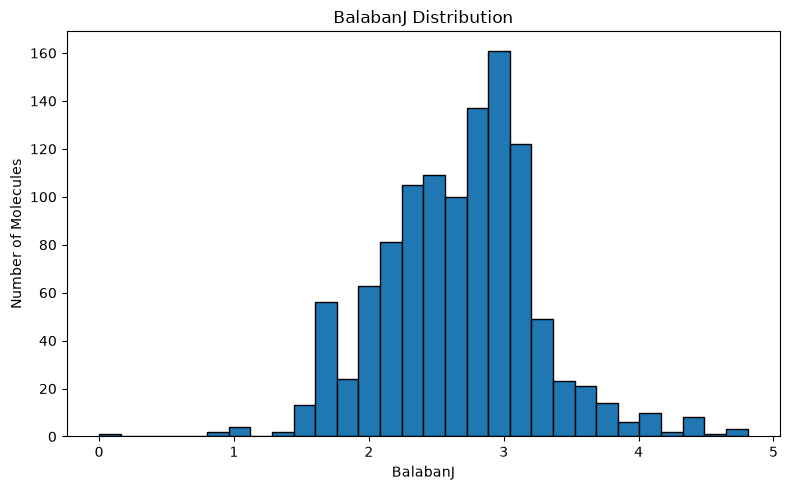

In [213]:
# Distribution plot

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    valid_data["BalabanJ"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.xlabel("BalabanJ")
plt.ylabel("Number of Molecules")
plt.title("BalabanJ Distribution")

plt.tight_layout()
plt.show()

In [214]:
# Inspect molecules with lowest BalabanJ
print("=" * 70)
print("LOWEST BALABANJ VALUES")
print("=" * 70)

display(
    valid_data[
        [
            "Compound ID",
            "smiles",
            "BalabanJ"
        ]
    ]
    .nsmallest(10, "BalabanJ")
)

LOWEST BALABANJ VALUES


,Compound ID,smiles,BalabanJ
934,Methane,C,0.000000
640,Digitoxin,CC1OC(OC2C(O)CC(OC3C(O)CC(OC4CCC5(C)C(CCC6C5CC...,0.826308
555,"Digoxin (L1=41,8mg/mL, L2=68,2mg/mL, Z=40,1mg/mL)",CC1OC(OC2C(O)CC(OC3C(O)CC(OC4CCC5(C)C(CCC6C5CC...,0.837498
146,Methanol,CO,1.000000
173,Iodomethane,CI,1.000000
581,Bromomethane,CBr,1.000000
600,Ethane,CC,1.000000
219,"Etoposide (148-167,25mg/ml)",COc1cc(C2c3cc4c(cc3C(OC3OC5COC(C)OC5C(O)C3O)C3...,1.318237
188,Diosgenin,CC1COC2CC3(C)C(CC4C5C=C6CC(O)CCC6(C)CC5CCC43C)...,1.330128
1030,Epitostanol,CC12CCC3C(CCC4CC5SC5CC43C)C1CCC2O,1.473731


In [215]:
# Inspect molecules with highest BalabanJ
print("=" * 70)
print("HIGHEST BALABANJ VALUES")
print("=" * 70)

display(
    valid_data[
        [
            "Compound ID",
            "smiles",
            "BalabanJ"
        ]
    ]
    .nlargest(10, "BalabanJ")
)

HIGHEST BALABANJ VALUES


,Compound ID,smiles,BalabanJ
354,Malathion,CCOC(=O)CC(SP(=S)(OC)OC)C(=O)OCC,4.807811
548,"Hexachloro-1,3-butadiene",ClC(Cl)=C(Cl)C(Cl)=C(Cl)Cl,4.708295
485,Trichlorfon,COP(=O)(OC)C(O)C(Cl)(Cl)Cl,4.657835
204,Propetamphos,CCNP(=S)(OC)OC(C)=CC(=O)OC(C)C,4.503498
804,Azodrin,CNC(=O)C=C(C)OP(=O)(OC)OC,4.442865
292,Dimecron,CCN(CC)C(=O)C(Cl)=CCOP(=O)(OC)OC,4.441295
1092,thiofanox,CNC(=O)ON=C(CSC)C(C)(C)C,4.411667
1124,Oxamyl,CNC(=O)ON=C(SC)C(=O)N(C)C,4.399366
956,Mecarbam,CCOC(=O)N(C)C(=O)CSP(=S)(OCC)OCC,4.397209
941,Triallate,CC(C)N(C(=O)SCC(Cl)=C(Cl)Cl)C(C)C,4.395102


In [216]:
# Create BalabanJ feature matrix
balaban_feature_matrix = valid_data[
    [
        "Compound ID",
        "BalabanJ"
    ]
].copy()


print("=" * 70)
print("BALABANJ FEATURE MATRIX")
print("=" * 70)

print(
    "Shape:",
    balaban_feature_matrix.shape
)

display(
    balaban_feature_matrix.head(10)
)

BALABANJ FEATURE MATRIX
Shape: (1117, 2)


,Compound ID,BalabanJ
0,Amigdalin,1.654937
1,Fenfuram,2.148162
2,citral,3.625760
3,Picene,2.041379
4,Thiophene,3.125000
5,benzothiazole,2.954660
6,"2,2,4,6,6'-PCB",2.774273
7,Estradiol,1.711200
8,Dieldrin,1.802907
9,Rotenone,1.581625


In [217]:
# Correlation with selected molecular descriptors
correlation_columns = [
    "BalabanJ"
]

# Add columns only if they already exist
for column in [
    "MW",
    "LogP",
    "TPSA",
    "HBD",
    "HBA",
    "Ring_Count",
    "Rotatable_Bonds",
    "Fraction_Csp3"
]:
    if column in valid_data.columns:
        correlation_columns.append(column)


print("=" * 70)
print("BALABANJ CORRELATION ANALYSIS")
print("=" * 70)

display(
    valid_data[correlation_columns]
    .corr()
    .round(3)
)

BALABANJ CORRELATION ANALYSIS


,BalabanJ,MW,LogP,LogP,TPSA,HBD,HBD,HBA,HBA
BalabanJ,1.000,-0.276,-0.119,-0.119,-0.099,-0.140,-0.140,-0.087,-0.087
MW,-0.276,1.000,0.478,0.478,0.480,0.261,0.261,0.560,0.560
LogP,-0.119,0.478,1.000,1.000,-0.438,-0.500,-0.500,-0.304,-0.304
LogP,-0.119,0.478,1.000,1.000,-0.438,-0.500,-0.500,-0.304,-0.304
TPSA,-0.099,0.480,-0.438,-0.438,1.000,0.755,0.755,0.899,0.899
HBD,-0.140,0.261,-0.500,-0.500,0.755,1.000,1.000,0.585,0.585
HBD,-0.140,0.261,-0.500,-0.500,0.755,1.000,1.000,0.585,0.585
HBA,-0.087,0.560,-0.304,-0.304,0.899,0.585,0.585,1.000,1.000
HBA,-0.087,0.560,-0.304,-0.304,0.899,0.585,0.585,1.000,1.000


### 28. BertzCT


In [218]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import GraphDescriptors

In [219]:
# Calculate BertzCT for one molecule
def calculate_bertzct(mol):

    if mol is None:
        return np.nan

    return GraphDescriptors.BertzCT(mol)

In [220]:
# Calculate BertzCT
valid_data["BertzCT"] = valid_data["mol"].apply(
    calculate_bertzct
)

In [ ]:
# Display BertzCT
print("=" * 70)
print("BERTZCT DESCRIPTOR")
print("=" * 70)

display(
    valid_data[
        [
            "Compound ID",
            "smiles",
            "BertzCT"
        ]
    ].head(10)
)

BERTZCT DESCRIPTOR


,Compound ID,smiles,BertzCT
0,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,759.662938
1,Fenfuram,Cc1occc1C(=O)Nc1ccccc1,459.484175
2,citral,CC(C)=CCCC(C)=CC=O,171.311799
3,Picene,c1ccc2c(c1)ccc1c2ccc2c3ccccc3ccc21,1071.547817
4,Thiophene,c1ccsc1,60.124818
5,benzothiazole,c1ccc2scnc2c1,282.893937
6,"2,2,4,6,6'-PCB",Clc1cc(Cl)c(-c2c(Cl)cccc2Cl)c(Cl)c1,533.848938
7,Estradiol,CC12CCC3c4ccc(O)cc4CCC3C1CCC2O,538.219802
8,Dieldrin,ClC1=C(Cl)C2(Cl)C3C4CC(C5OC45)C3C1(Cl)C2(Cl)Cl,516.422862
9,Rotenone,C=C(C)C1Cc2c(ccc3c2OC2COc4cc(OC)c(OC)cc4C2C3=O)O1,1040.148959


In [222]:
# Statistical summary

print("=" * 70)
print("BERTZCT STATISTICAL SUMMARY")
print("=" * 70)

bertz_summary = (
    valid_data["BertzCT"]
    .describe()
    .to_frame()
    .T
)

display(bertz_summary)

BERTZCT STATISTICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
BertzCT,1117.0,330.385098,276.361647,0.0,78.985336,271.015182,516.422862,1552.141814


In [223]:
# Missing values

print("=" * 70)
print("MISSING VALUES")
print("=" * 70)

print(
    "Missing BertzCT:",
    valid_data["BertzCT"].isna().sum()
)

MISSING VALUES
Missing BertzCT: 0


In [224]:
# Basic statistics
print("=" * 70)
print("BERTZCT RANGE")
print("=" * 70)

print("Minimum :", valid_data["BertzCT"].min())
print("Maximum :", valid_data["BertzCT"].max())
print("Mean    :", valid_data["BertzCT"].mean())
print("Median  :", valid_data["BertzCT"].median())
print("Std     :", valid_data["BertzCT"].std())

BERTZCT RANGE
Minimum : 0.0
Maximum : 1552.1418141649644
Mean    : 330.3850977294414
Median  : 271.01518240905483
Std     : 276.36164657179063


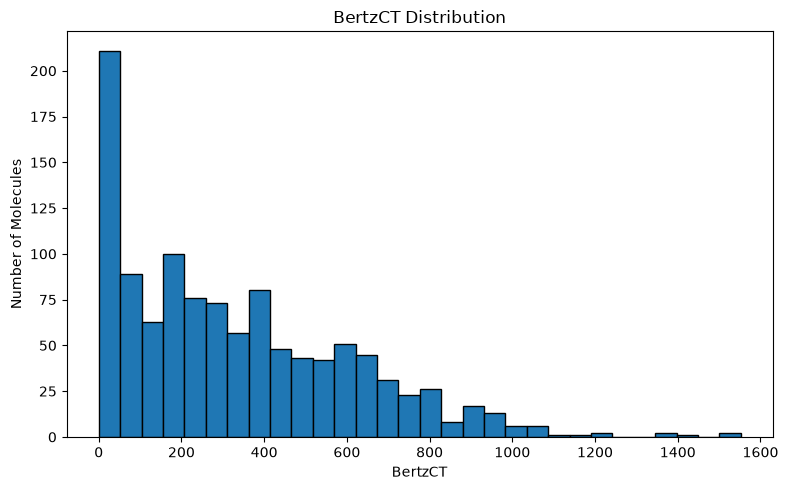

In [225]:
# BertzCT distribution

plt.figure(figsize=(8, 5))

plt.hist(
    valid_data["BertzCT"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.xlabel("BertzCT")
plt.ylabel("Number of Molecules")
plt.title("BertzCT Distribution")

plt.tight_layout()
plt.show()

In [226]:
# Lowest BertzCT molecules

print("=" * 70)
print("LOWEST BERTZCT VALUES")
print("=" * 70)

display(
    valid_data[
        [
            "Compound ID",
            "smiles",
            "BertzCT"
        ]
    ]
    .nsmallest(10, "BertzCT")
)


LOWEST BERTZCT VALUES


,Compound ID,smiles,BertzCT
494,Propane,CCC,0.000000
600,Ethane,CC,0.000000
689,Ethylene,C=C,0.000000
934,Methane,C,0.000000
146,Methanol,CO,2.000000
173,Iodomethane,CI,2.000000
581,Bromomethane,CBr,2.000000
1068,Butane,CCCC,2.000000
103,Dichloromethane,ClCCl,2.754888
201,Methyl hydrazine,CNN,2.754888


In [227]:
# Highest BertzCT molecules

print("=" * 70)
print("HIGHEST BERTZCT VALUES")
print("=" * 70)

display(
    valid_data[
        [
            "Compound ID",
            "smiles",
            "BertzCT"
        ]
    ]
    .nlargest(10, "BertzCT")
)

HIGHEST BERTZCT VALUES


,Compound ID,smiles,BertzCT
922,norbormide,O=C1NC(=O)C2C3C(C(O)(c4ccccc4)c4ccccn4)=CC(C3=...,1552.141814
939,bromadiolone,O=c1oc2ccccc2c(O)c1C(CC(O)c1ccc(-c2ccc(Br)cc2)...,1507.150749
555,"Digoxin (L1=41,8mg/mL, L2=68,2mg/mL, Z=40,1mg/mL)",CC1OC(OC2C(O)CC(OC3C(O)CC(OC4CCC5(C)C(CCC6C5CC...,1409.003742
640,Digitoxin,CC1OC(OC2C(O)CC(OC3C(O)CC(OC4CCC5(C)C(CCC6C5CC...,1374.417685
219,"Etoposide (148-167,25mg/ml)",COc1cc(C2c3cc4c(cc3C(OC3OC5COC(C)OC5C(O)C3O)C3...,1352.532560
482,Fluvalinate,CC(C)C(Nc1ccc(C(F)(F)F)cc1Cl)C(=O)OC(C#N)c1ccc...,1210.454153
676,Benzo[ghi]perylene,c1cc2ccc3ccc4ccc5cccc6c(c1)c2c3c4c56,1193.645130
718,Coronene,c1cc2ccc3ccc4ccc5ccc6ccc1c1c2c3c4c5c61,1140.946635
86,Flucythrinate,CC(C)C(C(=O)OC(C#N)c1cccc(Oc2ccccc2)c1)c1ccc(O...,1095.279678
861,Bendroflumethiazide,NS(=O)(=O)c1cc2c(cc1C(F)(F)F)NC(Cc1ccccc1)NS2(...,1085.280492


In [228]:
# Correlation with other descriptors

correlation_columns = ["BertzCT"]

for column in [
    "MW",
    "LogP",
    "TPSA",
    "HBD",
    "HBA",
    "Ring_Count",
    "Rotatable_Bonds",
    "Fraction_Csp3",
    "BalabanJ",
    "Kappa1",
    "Kappa2",
    "Kappa3"
]:

    if column in valid_data.columns:
        correlation_columns.append(column)


print("=" * 70)
print("BERTZCT CORRELATION ANALYSIS")
print("=" * 70)

display(
    valid_data[correlation_columns]
    .corr()
    .round(3)
)

BERTZCT CORRELATION ANALYSIS


,BertzCT,MW,LogP,LogP,TPSA,HBD,HBD,HBA,HBA,BalabanJ,Kappa1,Kappa2,Kappa3
BertzCT,1.000,0.821,0.387,0.387,0.490,0.255,0.255,0.497,0.497,-0.402,0.743,0.370,-0.049
MW,0.821,1.000,0.478,0.478,0.480,0.261,0.261,0.560,0.560,-0.276,0.930,0.634,-0.031
LogP,0.387,0.478,1.000,1.000,-0.438,-0.500,-0.500,-0.304,-0.304,-0.119,0.410,0.410,-0.017
LogP,0.387,0.478,1.000,1.000,-0.438,-0.500,-0.500,-0.304,-0.304,-0.119,0.410,0.410,-0.017
TPSA,0.490,0.480,-0.438,-0.438,1.000,0.755,0.755,0.899,0.899,-0.099,0.547,0.295,-0.017
HBD,0.255,0.261,-0.500,-0.500,0.755,1.000,1.000,0.585,0.585,-0.140,0.304,0.125,0.001
HBD,0.255,0.261,-0.500,-0.500,0.755,1.000,1.000,0.585,0.585,-0.140,0.304,0.125,0.001
HBA,0.497,0.560,-0.304,-0.304,0.899,0.585,0.585,1.000,1.000,-0.087,0.646,0.435,-0.012
HBA,0.497,0.560,-0.304,-0.304,0.899,0.585,0.585,1.000,1.000,-0.087,0.646,0.435,-0.012
BalabanJ,-0.402,-0.276,-0.119,-0.119,-0.099,-0.140,-0.140,-0.087,-0.087,1.000,-0.223,-0.124,-0.009


In [229]:
# Create BertzCT feature matrix

bertz_feature_matrix = valid_data[
    [
        "Compound ID",
        "BertzCT"
    ]
].copy()


print("=" * 70)
print("BERTZCT FEATURE MATRIX")
print("=" * 70)

print(
    "Shape:",
    bertz_feature_matrix.shape
)

display(
    bertz_feature_matrix.head(10)
)

BERTZCT FEATURE MATRIX
Shape: (1117, 2)


,Compound ID,BertzCT
0,Amigdalin,759.662938
1,Fenfuram,459.484175
2,citral,171.311799
3,Picene,1071.547817
4,Thiophene,60.124818
5,benzothiazole,282.893937
6,"2,2,4,6,6'-PCB",533.848938
7,Estradiol,538.219802
8,Dieldrin,516.422862
9,Rotenone,1040.148959


In [230]:
# Example molecule

example_idx = valid_data.index[0]

print("=" * 70)
print("EXAMPLE MOLECULE")
print("=" * 70)

print(
    "Compound:",
    valid_data.loc[example_idx, "Compound ID"]
)

print(
    "SMILES:",
    valid_data.loc[example_idx, "smiles"]
)

print(
    "BertzCT:",
    valid_data.loc[example_idx, "BertzCT"]
)

EXAMPLE MOLECULE
Compound: Amigdalin
SMILES: N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c1ccccc1
BertzCT: 759.6629378441625


## Part IV — Molecular Fingerprints

### 31. What Are Molecular Fingerprints?

* Morgan Fingerprints
* ECFP concept
* Fingerprint bit representation
* Fingerprint visualization
* Other fingerprints
    * MACCS
    * RDKit fingerprints
    * Atom-pair fingerprints
    * Topological torsion fingerprints

* Molecular similarity


In [231]:
from rdkit import Chem
from rdkit.Chem import (
    rdFingerprintGenerator,
    MACCSkeys
)


morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

rdkit_generator = rdFingerprintGenerator.GetRDKitFPGenerator(
    fpSize=2048
)

atom_pair_generator = (
    rdFingerprintGenerator.GetAtomPairGenerator(
        fpSize=2048
    )
)

torsion_generator = (
    rdFingerprintGenerator.GetTopologicalTorsionGenerator(
        fpSize=2048
    )
)


def generate_fingerprints(mol):

    return {
        "Morgan": morgan_generator.GetFingerprint(mol),

        "MACCS": MACCSkeys.GenMACCSKeys(mol),

        "RDKit": rdkit_generator.GetFingerprint(mol),

        "AtomPair": atom_pair_generator.GetFingerprint(mol),

        "TopologicalTorsion":
            torsion_generator.GetFingerprint(mol),
    }

In [232]:
fps = generate_fingerprints(mol)

for name, fp in fps.items():
    print(
        f"{name:20} → {len(fp)} bits"
    )

Morgan               → 2048 bits
MACCS                → 167 bits
RDKit                → 2048 bits
AtomPair             → 2048 bits
TopologicalTorsion   → 2048 bits


### 32. Morgan / ECFP


In [233]:
valid_data["morgan_fp"] = valid_data["mol"].apply(
    morgan_generator.GetFingerprint
)

valid_data["maccs_fp"] = valid_data["mol"].apply(
    MACCSkeys.GenMACCSKeys
)

valid_data["rdkit_fp"] = valid_data["mol"].apply(
    rdkit_generator.GetFingerprint
)

valid_data["atom_pair_fp"] = valid_data["mol"].apply(
    atom_pair_generator.GetFingerprint
)

valid_data["torsion_fp"] = valid_data["mol"].apply(
    torsion_generator.GetFingerprint
)

In [234]:
# Molecular Similarity

mol_a = valid_data.iloc[0]["mol"]
mol_b = valid_data.iloc[1]["mol"]

fp_a = morgan_generator.GetFingerprint(mol_a)
fp_b = morgan_generator.GetFingerprint(mol_b)

similarity = DataStructs.TanimotoSimilarity(
    fp_a,
    fp_b
)

print("Tanimoto similarity:", similarity)


Tanimoto similarity: 0.12307692307692308


In [235]:
# Similarity Search

query_mol = valid_data.iloc[0]["mol"]

query_fp = morgan_generator.GetFingerprint(
    query_mol
)


In [236]:
similarities = []

for idx, row in valid_data.iterrows():

    fp = morgan_generator.GetFingerprint(
        row["mol"]
    )

    score = DataStructs.TanimotoSimilarity(
        query_fp,
        fp
    )

    similarities.append({
        "index": idx,
        "Compound ID": row["Compound ID"],
        "SMILES": row["smiles"],
        "Tanimoto": score
    })

In [237]:
similarity_df = (
    pd.DataFrame(similarities)
    .sort_values(
        "Tanimoto",
        ascending=False
    )
)

In [238]:
similarity_df.head(10)

,index,Compound ID,SMILES,Tanimoto
0,0,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,1.000000
297,298,Raffinose,OCC1OC(OCC2OC(OC3(CO)OC(CO)C(O)C3O)C(O)C(O)C2O...,0.438596
534,537,Salicin,OCc1ccccc1OC1OC(CO)C(O)C(O)C1O,0.425926
1040,1050,Monotropitoside,COC(=O)c1ccccc1OC1OC(COC2OCC(O)C(O)C2O)C(O)C(O...,0.367647
1015,1025,Sucrose,OCC1OC(OC2(CO)OC(CO)C(O)C2O)C(O)C(O)C1O,0.333333
440,441,Lactose,OCC1OC(OC2C(CO)OC(O)C(O)C2O)C(O)C(O)C1O,0.333333
340,341,glucose,OCC1OC(O)C(O)C(O)C1O,0.297872
893,901,Fenpropathrin,CC1(C)C(C(=O)OC(C#N)c2cccc(Oc3ccccc3)c2)C1(C)C,0.264706
150,150,tubercidin,Nc1ncnc2c1ccn2C1OC(CO)C(O)C1O,0.253731
457,458,Cypermethrin,CC1(C)C(C=C(Cl)Cl)C1C(=O)OC(C#N)c1cccc(Oc2cccc...,0.253333


## Part VII — Dataset Analysis

### 49. Molecular Summary DataFrame

### 50. Descriptor Distributions

* MW distribution
* LogP distribution
* TPSA distribution
* HBD distribution
* HBA distribution
* Ring count distribution


In [239]:
# Molecular Weight Distribution
plt.figure(figsize=(8, 5))

plt.hist(
    summary_df["MW"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Molecular Weight (Da)")
plt.ylabel("Number of Molecules")
plt.title("Molecular Weight Distribution")

plt.show()

NameError: name 'summary_df' is not defined

<Figure size 800x500 with 0 Axes>

In [ ]:
summary_df["MW"].describe()

In [ ]:
# LogP Distribution

plt.figure(figsize=(8, 5))

plt.hist(
    summary_df["LogP"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("LogP")
plt.ylabel("Number of Molecules")
plt.title("LogP Distribution")

plt.show()

In [ ]:
summary_df["LogP"].describe()

In [ ]:
summary_df.nlargest(
    10,
    "LogP"
)[
    ["Compound ID", "SMILES", "LogP"]
]

In [ ]:
summary_df.nsmallest(
    10,
    "LogP"
)[
    ["Compound ID", "SMILES", "LogP"]
]

In [ ]:
# TPSA Distribution
plt.figure(figsize=(8, 5))

plt.hist(
    summary_df["TPSA"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("TPSA (Å²)")
plt.ylabel("Number of Molecules")
plt.title("TPSA Distribution")

plt.show()

In [ ]:
summary_df["TPSA"].describe()

In [ ]:
summary_df.nlargest(
    10,
    "TPSA"
)[
    ["Compound ID", "SMILES", "TPSA"]
]

In [ ]:
# HBD Distribution
hbd_counts = summary_df["HBD"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(
    hbd_counts.index,
    hbd_counts.values
)

plt.xlabel("Hydrogen Bond Donors (HBD)")
plt.ylabel("Number of Molecules")
plt.title("HBD Distribution")

plt.xticks(hbd_counts.index)

plt.show()


In [ ]:
hbd_counts

In [ ]:
# HBA Distribution
hba_counts = summary_df["HBA"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(
    hba_counts.index,
    hba_counts.values
)

plt.xlabel("Hydrogen Bond Acceptors (HBA)")
plt.ylabel("Number of Molecules")
plt.title("HBA Distribution")

plt.xticks(hba_counts.index)

plt.show()

In [ ]:
summary_df["HBA"].describe()

In [ ]:
# Ring Count Distribution

ring_counts = summary_df["Rings"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(
    ring_counts.index,
    ring_counts.values
)

plt.xlabel("Number of Rings")
plt.ylabel("Number of Molecules")
plt.title("Ring Count Distribution")

plt.xticks(ring_counts.index)

plt.show()


In [ ]:
ring_counts

In [ ]:
continuous_descriptors = [
    ("MW", "Molecular Weight (Da)"),
    ("LogP", "LogP"),
    ("TPSA", "TPSA (Å²)")
]

discrete_descriptors = [
    ("HBD", "Hydrogen Bond Donors"),
    ("HBA", "Hydrogen Bond Acceptors"),
    ("Rings", "Number of Rings")
]

### 51. Property Correlations

`	ext
MW ↔ LogP
MW ↔ TPSA
LogP ↔ ESOL
TPSA ↔ ESOL
`


In [ ]:
# ESOL predicted logS from the original dataset
esol_column = "ESOL_LogS"

if esol_column not in valid_data.columns:

    if esol_column in summary_df.columns:
        valid_data[esol_column] = summary_df.loc[
            valid_data.index,
            esol_column
        ]

    else:
        valid_data[esol_column] = valid_data[
            "ESOL predicted log solubility in mols per litre"
        ]


correlation_columns = [
    "MW",
    "LogP",
    "TPSA",
    "ESOL_LogS"
]

In [ ]:
# Create clean correlation DataFrame
correlation_df = valid_data[
    correlation_columns
].copy()

correlation_df = correlation_df.dropna()


print("=" * 70)
print("PROPERTY CORRELATION DATA")
print("=" * 70)

print(
    "Number of molecules:",
    len(correlation_df)
)

display(
    correlation_df.head(10)
)

In [ ]:
# Pearson correlation
pearson_corr = correlation_df.corr(
    method="pearson"
)


print("=" * 70)
print("PEARSON CORRELATION")
print("=" * 70)

display(
    pearson_corr.round(3)
)

In [ ]:
# Spearman correlation
spearman_corr = correlation_df.corr(
    method="spearman"
)


print("=" * 70)
print("SPEARMAN CORRELATION")
print("=" * 70)

display(
    spearman_corr.round(3)
)

In [ ]:
# Full correlation matrix visualization
plt.figure(figsize=(8, 6))

plt.imshow(
    pearson_corr,
    interpolation="nearest",
    aspect="auto"
)

plt.colorbar(
    label="Pearson Correlation"
)

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_columns)),
    correlation_columns
)

plt.title(
    "Molecular Property Correlation Matrix"
)

# Add correlation values
for i in range(len(correlation_columns)):
    for j in range(len(correlation_columns)):

        value = pearson_corr.iloc[i, j]

        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()


In [ ]:
# 6. Scatter plot function

def plot_correlation(
    df,
    x,
    y,
    xlabel=None,
    ylabel=None,
    title=None
):

    x_values = df[x]
    y_values = df[y]

    pearson = x_values.corr(
        y_values,
        method="pearson"
    )

    spearman = x_values.corr(
        y_values,
        method="spearman"
    )

    plt.figure(figsize=(8, 5))

    plt.scatter(
        x_values,
        y_values,
        alpha=0.6
    )

    plt.xlabel(
        xlabel if xlabel else x
    )

    plt.ylabel(
        ylabel if ylabel else y
    )

    plt.title(
        title
        if title
        else f"{x} vs {y}"
    )

    plt.text(
        0.05,
        0.95,
        f"Pearson r = {pearson:.3f}\n"
        f"Spearman ρ = {spearman:.3f}",
        transform=plt.gca().transAxes,
        verticalalignment="top"
    )

    plt.tight_layout()
    plt.show()

In [ ]:
# 12. Identify strongest pairwise correlation

corr_matrix = pearson_corr.copy()

# Remove diagonal
np.fill_diagonal(
    corr_matrix.values,
    np.nan
)

strongest_pair = (
    corr_matrix
    .abs()
    .stack()
    .sort_values(
        ascending=False
    )
)

print("=" * 70)
print("STRONGEST PAIRWISE CORRELATIONS")
print("=" * 70)

display(
    strongest_pair.head(6)
)

### 52. Outlier Detection
> For your Molecular Structure & Property Explorer, this section should identify molecules that are unusual compared with the rest of the ESOL dataset.

* Extremely high MW
* Extremely high LogP
* Extremely high TPSA
* Unusual charge
* Unusual ring systems


In [240]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

In [241]:
# Make sure required descriptors exist

if "MW" not in valid_data.columns:
    valid_data["MW"] = valid_data["mol"].apply(
        lambda mol: rdMolDescriptors.CalcExactMolWt(mol)
    )

if "LogP" not in valid_data.columns:
    from rdkit.Chem import Crippen

    valid_data["LogP"] = valid_data["mol"].apply(
        Crippen.MolLogP
    )

if "TPSA" not in valid_data.columns:
    valid_data["TPSA"] = valid_data["mol"].apply(
        rdMolDescriptors.CalcTPSA
    )

if "Formal_Charge" not in valid_data.columns:
    valid_data["Formal_Charge"] = valid_data["mol"].apply(
        Chem.GetFormalCharge
    )

if "Ring_Count" not in valid_data.columns:
    valid_data["Ring_Count"] = valid_data["mol"].apply(
        rdMolDescriptors.CalcNumRings
    )

if "Aromatic_Ring_Count" not in valid_data.columns:
    valid_data["Aromatic_Ring_Count"] = valid_data["mol"].apply(
        rdMolDescriptors.CalcNumAromaticRings
    )

In [242]:
# IQR-based outlier detection

def iqr_bounds(series):

    series = series.dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return lower, upper

In [243]:
# MW outliers

mw_lower, mw_upper = iqr_bounds(
    valid_data["MW"]
)

valid_data["MW_Outlier"] = (
    (valid_data["MW"] < mw_lower) |
    (valid_data["MW"] > mw_upper)
)

In [244]:
# LogP outliers

logp_lower, logp_upper = iqr_bounds(
    valid_data["LogP"]
)

valid_data["LogP_Outlier"] = (
    (valid_data["LogP"] < logp_lower) |
    (valid_data["LogP"] > logp_upper)
)

ValueError: Cannot set a DataFrame with multiple columns to the single column LogP_Outlier

In [245]:
# TPSA outliers

tpsa_lower, tpsa_upper = iqr_bounds(
    valid_data["TPSA"]
)

valid_data["TPSA_Outlier"] = (
    (valid_data["TPSA"] < tpsa_lower) |
    (valid_data["TPSA"] > tpsa_upper)
)

In [246]:
# Unusual charge

valid_data["Unusual_Charge"] = (
    valid_data["Formal_Charge"] != 0
)

In [247]:
# Unusual ring systems

ring_lower, ring_upper = iqr_bounds(
    valid_data["Ring_Count"]
)

valid_data["Unusual_Ring_System"] = (
    (valid_data["Ring_Count"] < ring_lower) |
    (valid_data["Ring_Count"] > ring_upper)
)

In [ ]:
# Overall outlier flag
outlier_flags = [
    "MW_Outlier",
    "LogP_Outlier",
    "TPSA_Outlier",
    "Unusual_Charge",
    "Unusual_Ring_System"
]

valid_data["Any_Outlier"] = (
    valid_data[outlier_flags]
    .any(axis=1)
)

KeyError: "['LogP_Outlier'] not in index"

In [249]:
# Outlier score

valid_data["Outlier_Count"] = (
    valid_data[outlier_flags]
    .sum(axis=1)
)

KeyError: "['LogP_Outlier'] not in index"

In [250]:
# Display threshold information

print("=" * 75)
print("OUTLIER THRESHOLDS")
print("=" * 75)

print(f"MW    : < {mw_lower:.3f} or > {mw_upper:.3f}")
print(f"LogP  : < {logp_lower:.3f} or > {logp_upper:.3f}")
print(f"TPSA  : < {tpsa_lower:.3f} or > {tpsa_upper:.3f}")
print(f"Rings : < {ring_lower:.3f} or > {ring_upper:.3f}")


OUTLIER THRESHOLDS
MW    : < -104.001 or > 494.996


TypeError: unsupported format string passed to Series.__format__

In [251]:
# Summary of detected outliers

print("\n" + "=" * 75)
print("OUTLIER SUMMARY")
print("=" * 75)

outlier_summary = pd.DataFrame({
    "Category": [
        "MW",
        "LogP",
        "TPSA",
        "Unusual Charge",
        "Unusual Ring System"
    ],

    "Number of Outliers": [
        valid_data["MW_Outlier"].sum(),
        valid_data["LogP_Outlier"].sum(),
        valid_data["TPSA_Outlier"].sum(),
        valid_data["Unusual_Charge"].sum(),
        valid_data["Unusual_Ring_System"].sum()
    ]
})

outlier_summary["Percentage"] = (
    outlier_summary["Number of Outliers"]
    / len(valid_data)
    * 100
)

display(
    outlier_summary.round(2)
)


OUTLIER SUMMARY


KeyError: 'LogP_Outlier'

In [252]:
# Extremely high MW molecules

print("=" * 75)
print("EXTREMELY HIGH MOLECULAR WEIGHT")
print("=" * 75)

display(
    valid_data[
        [
            "Compound ID",
            "smiles",
            "MW",
            "LogP",
            "TPSA"
        ]
    ]
    .sort_values(
        "MW",
        ascending=False
    )
    .head(10)
)

EXTREMELY HIGH MOLECULAR WEIGHT


,Compound ID,smiles,MW,LogP,LogP,TPSA
555,"Digoxin (L1=41,8mg/mL, L2=68,2mg/mL, Z=40,1mg/mL)",CC1OC(OC2C(O)CC(OC3C(O)CC(OC4CCC5(C)C(CCC6C5CC...,780.949,2.21810,2.21810,203.06
640,Digitoxin,CC1OC(OC2C(O)CC(OC3C(O)CC(OC4CCC5(C)C(CCC6C5CC...,764.950,3.24730,3.24730,182.83
219,"Etoposide (148-167,25mg/ml)",COc1cc(C2c3cc4c(cc3C(OC3OC5COC(C)OC5C(O)C3O)C3...,588.562,1.33860,1.33860,160.83
988,Mirex,ClC1(Cl)C2(Cl)C3(Cl)C4(Cl)C(Cl)(Cl)C5(Cl)C3(Cl...,545.546,6.22300,6.22300,0.00
939,bromadiolone,O=c1oc2ccccc2c(O)c1C(CC(O)c1ccc(-c2ccc(Br)cc2)...,527.414,7.18370,7.18370,70.67
922,norbormide,O=C1NC(=O)C2C3C(C(O)(c4ccccc4)c4ccccn4)=CC(C3=...,511.581,4.28940,4.28940,92.18
272,Deltamethrin,CC1(C)C(C=C(Br)Br)C1C(=O)OC(C#N)c1cccc(Oc2cccc...,505.206,6.49018,6.49018,59.32
298,Raffinose,OCC1OC(OCC2OC(OC3(CO)OC(CO)C(O)C3O)C(O)C(O)C2O...,504.438,-7.57140,-7.57140,268.68
482,Fluvalinate,CC(C)C(Nc1ccc(C(F)(F)F)cc1Cl)C(=O)OC(C#N)c1ccc...,502.920,7.39568,7.39568,71.35
603,"2,2',3,3',4,4',5,5',6,6'-PCB",Clc1c(Cl)c(Cl)c(-c2c(Cl)c(Cl)c(Cl)c(Cl)c2Cl)c(...,498.662,9.88760,9.88760,0.00


In [253]:
# Extremely high LogP molecules

print("=" * 75)
print("EXTREMELY HIGH LOGP")
print("=" * 75)

display(
    valid_data[
        [
            "Compound ID",
            "smiles",
            "MW",
            "LogP",
            "TPSA"
        ]
    ]
    .sort_values(
        "LogP",
        ascending=False
    )
    .head(10)
)

EXTREMELY HIGH LOGP


ValueError: The column label 'LogP' is not unique.

In [254]:
# Extremely high TPSA molecules

print("=" * 75)
print("EXTREMELY HIGH TPSA")
print("=" * 75)

display(
    valid_data[
        [
            "Compound ID",
            "smiles",
            "MW",
            "LogP",
            "TPSA"
        ]
    ]
    .sort_values(
        "TPSA",
        ascending=False
    )
    .head(10)
)

EXTREMELY HIGH TPSA


,Compound ID,smiles,MW,LogP,LogP,TPSA
298,Raffinose,OCC1OC(OCC2OC(OC3(CO)OC(CO)C(O)C3O)C(O)C(O)C2O...,504.438,-7.57140,-7.57140,268.68
555,"Digoxin (L1=41,8mg/mL, L2=68,2mg/mL, Z=40,1mg/mL)",CC1OC(OC2C(O)CC(OC3C(O)CC(OC4CCC5(C)C(CCC6C5CC...,780.949,2.21810,2.21810,203.06
0,Amigdalin,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,457.432,-3.10802,-3.10802,202.32
733,alloxantin,O=C1NC(=O)C(O)(C2(O)C(=O)NC(=O)NC2=O)C(=O)N1,286.156,-4.81940,-4.81940,191.00
1025,Sucrose,OCC1OC(OC2(CO)OC(CO)C(O)C2O)C(O)C(O)C1O,342.297,-5.39560,-5.39560,189.53
441,Lactose,OCC1OC(OC2C(CO)OC(O)C(O)C2O)C(O)C(O)C1O,342.297,-5.39720,-5.39720,189.53
1050,Monotropitoside,COC(=O)c1ccccc1OC1OC(COC2OCC(O)C(O)C2O)C(O)C(O...,446.405,-2.88480,-2.88480,184.60
640,Digitoxin,CC1OC(OC2C(O)CC(OC3C(O)CC(OC4CCC5(C)C(CCC6C5CC...,764.950,3.24730,3.24730,182.83
588,Riboflavin,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(CC(O)C(O)C(O)CO)c...,376.369,-1.72356,-1.72356,161.56
219,"Etoposide (148-167,25mg/ml)",COc1cc(C2c3cc4c(cc3C(OC3OC5COC(C)OC5C(O)C3O)C3...,588.562,1.33860,1.33860,160.83


In [255]:
# Unusual charge

print("=" * 75)
print("UNUSUAL CHARGE")
print("=" * 75)

display(
    valid_data[
        valid_data["Unusual_Charge"]
    ][
        [
            "Compound ID",
            "smiles",
            "Formal_Charge",
            "MW",
            "LogP",
            "TPSA"
        ]
    ]
    .sort_values(
        "Formal_Charge"
    )
    .head(20)
)


UNUSUAL CHARGE


,Compound ID,smiles,Formal_Charge,MW,LogP,LogP,TPSA


In [256]:
# Unusual ring systems

print("=" * 75)
print("UNUSUAL RING SYSTEMS")
print("=" * 75)

display(
    valid_data[
        valid_data["Unusual_Ring_System"]
    ][
        [
            "Compound ID",
            "smiles",
            "Ring_Count",
            "Aromatic_Ring_Count",
            "MW",
            "LogP"
        ]
    ]
    .sort_values(
        "Ring_Count",
        ascending=False
    )
    .head(20)
)

UNUSUAL RING SYSTEMS


,Compound ID,smiles,Ring_Count,Aromatic_Ring_Count,MW,LogP,LogP
640,Digitoxin,CC1OC(OC2C(O)CC(OC3C(O)CC(OC4CCC5(C)C(CCC6C5CC...,8,0,764.950,3.2473,3.2473
555,"Digoxin (L1=41,8mg/mL, L2=68,2mg/mL, Z=40,1mg/mL)",CC1OC(OC2C(O)CC(OC3C(O)CC(OC4CCC5(C)C(CCC6C5CC...,8,0,780.949,2.2181,2.2181
922,norbormide,O=C1NC(=O)C2C3C(C(O)(c4ccccc4)c4ccccn4)=CC(C3=...,7,4,511.581,4.2894,4.2894
219,"Etoposide (148-167,25mg/ml)",COc1cc(C2c3cc4c(cc3C(OC3OC5COC(C)OC5C(O)C3O)C3...,7,2,588.562,1.3386,1.3386
718,Coronene,c1cc2ccc3ccc4ccc5ccc6ccc1c1c2c3c4c5c61,7,7,300.360,6.9192,6.9192
188,Diosgenin,CC1COC2CC3(C)C(CC4C5C=C6CC(O)CCC6(C)CC5CCC43C)...,6,0,414.630,5.5088,5.5088
429,Kepone,O=C1C2(Cl)C3(Cl)C4(Cl)C(Cl)(Cl)C5(Cl)C3(Cl)C1(...,6,0,490.639,4.6182,4.6182
676,Benzo[ghi]perylene,c1cc2ccc3ccc4ccc5cccc6c(c1)c2c3c4c56,6,6,276.338,6.3282,6.3282
988,Mirex,ClC1(Cl)C2(Cl)C3(Cl)C4(Cl)C(Cl)(Cl)C5(Cl)C3(Cl...,6,0,545.546,6.2230,6.2230


In [257]:
# Molecules with multiple outlier flags

print("=" * 75)
print("MOLECULES WITH MULTIPLE OUTLIER FLAGS")
print("=" * 75)

multi_outliers = (
    valid_data[
        valid_data["Outlier_Count"] >= 2
    ][
        [
            "Compound ID",
            "smiles",
            "MW",
            "LogP",
            "TPSA",
            "Formal_Charge",
            "Ring_Count",
            "Outlier_Count"
        ] + outlier_flags
    ]
    .sort_values(
        "Outlier_Count",
        ascending=False
    )
)

display(
    multi_outliers.head(20)
)

MOLECULES WITH MULTIPLE OUTLIER FLAGS


KeyError: 'Outlier_Count'

In [258]:
# Outlier distribution visualization

plt.figure(figsize=(8, 5))

plt.bar(
    outlier_summary["Category"],
    outlier_summary["Number of Outliers"]
)

plt.xlabel("Outlier Category")
plt.ylabel("Number of Molecules")
plt.title("Molecular Outlier Summary")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()

NameError: name 'outlier_summary' is not defined

<Figure size 800x500 with 0 Axes>

In [259]:
# MW vs LogP — highlight outliers

plt.figure(figsize=(8, 5))

normal = ~valid_data["Any_Outlier"]
outlier = valid_data["Any_Outlier"]

plt.scatter(
    valid_data.loc[normal, "MW"],
    valid_data.loc[normal, "LogP"],
    alpha=0.5,
    label="Non-outlier"
)

plt.scatter(
    valid_data.loc[outlier, "MW"],
    valid_data.loc[outlier, "LogP"],
    alpha=0.8,
    label="Outlier"
)

plt.xlabel("Molecular Weight (Da)")
plt.ylabel("LogP")
plt.title("MW vs LogP — Outlier Detection")
plt.legend()

plt.tight_layout()
plt.show()

KeyError: 'Any_Outlier'

<Figure size 800x500 with 0 Axes>

In [260]:
# Final outlier dataset

outlier_dataset = valid_data[
    valid_data["Any_Outlier"]
].copy()

print("=" * 75)
print("FINAL OUTLIER DATASET")
print("=" * 75)

print(
    "Total valid molecules:",
    len(valid_data)
)

print(
    "Molecules with ≥1 outlier flag:",
    len(outlier_dataset)
)

print(
    "Percentage:",
    f"{len(outlier_dataset) / len(valid_data) * 100:.2f}%"
)

display(
    outlier_dataset[
        [
            "Compound ID",
            "smiles",
            "MW",
            "LogP",
            "TPSA",
            "Formal_Charge",
            "Ring_Count",
            "Aromatic_Ring_Count",
            "Outlier_Count"
        ] + outlier_flags
    ].head(20)
)

KeyError: 'Any_Outlier'

## Part VIII — Final Application

### 54. Build Molecule Explorer
